# Clasificación binaria del resultado de infección por VPH

**Proyecto.** Sistema Telemático de Apoyo Clínico para la Estimación de Riesgo de VPH y Lesiones Precancerosas del Cuello Uterino

**Institución.** Universidad del Cauca, Popayán, Cauca

**Metodología.** CRISP-ML(Q)

**Dataset.** `BD_Infección VPH_Para imputar - Sin ID.xlsx`

**Por**:
* `JOSE MARTIN GONZALEZ JOAQUI`
* `BRIYITH VANEZA GUACAS NARVAEZ`
* `KAROL TATIANA PALECHOR VALENCIA`
* `YULIETH GABRIELA JARAMILLO YELA`





## ¿Por qué CRISP-ML(Q)?

CRISP-ML(Q) es un marco metodológico diseñado específicamente para guiar el desarrollo de aplicaciones de Machine Learning con aseguramiento de calidad. A diferencia de enfoques ad hoc o de marcos genéricos de ciencia de datos, CRISP-ML(Q) incorpora verificaciones de calidad en cada fase del ciclo de vida del modelo, lo cual resulta fundamental cuando el modelo se aplica en un contexto de salud pública.

En este proyecto, el modelo predictivo se utilizará como herramienta de apoyo a la decisión clínica del personal de enfermería del Centro de Salud Alfonso López. Esto implica que los errores del modelo tienen consecuencias directas sobre pacientes reales. La trazabilidad de cada decisión técnica, la reproducibilidad de los experimentos, la prevención de errores metodológicos y la evaluación rigurosa del desempeño no son opcionales, sino requisitos esenciales del proceso.

Las seis fases de CRISP-ML(Q) se describen brevemente a continuación.

1. **Business and Data Understanding.** Comprensión del problema de negocio y exploración de los datos disponibles.
2. **Data Engineering.** Preprocesamiento, limpieza, codificación y transformación del dataset.
3. **Model Engineering.** Selección, entrenamiento y ajuste de los modelos de Machine Learning.
4. **Model Evaluation.** Evaluación del desempeño con métricas apropiadas y validación de los resultados.
5. **Model Deployment.** Despliegue del modelo en un entorno de producción o prototipo funcional.
6. **Monitoring and Maintenance.** Supervisión continua del modelo en operación.


Se persiguen tres objetivos. Primero se reproduce el modelo estadístico de referencia ya existente, una regresión logística clínica que modela con curvas suaves la edad y el número de hijos, y se aplica al dataset proporcionado por el centro de salud `BD_Infección VPH_Para imputar - Sin ID.xlsx` para medir el rendimiento que alcanza aquí. Después se enfrenta ese modelo base a una batería de modelos de aprendizaje automático que incluye una red neuronal, y se corona al que logra el equilibrio más sano en su matriz de confusión, es decir un buen puntaje F1 sin disparar los falsos positivos. Por último se exporta al ganador junto con su punto de corte para que el prototipo lo cargue y entregue, ante cualquier paciente, la probabilidad de resultado positivo de VPH expresada como porcentaje de riesgo, que es lo que el personal de salud necesita para priorizar.

 En la Sección 0 se reconstruye el modelo de referencia. En la Fase 1 se comprenden el problema clínico y los datos. En la Fase 2 se preparan los datos y se decide cómo tratar el desbalance. En la Fase 3 se entrenan y comparan los modelos y se corona al ganador. En la Fase 4 se evalúa al campeón sobre datos que nunca vio y se decide su uso. En la Sección 5 se exporta el modelo elegido. Cada fase abre con una descripción de lo que se va a hacer y cierra con un análisis de lo que se obtuvo.

El conjunto de datos original sobre el que se construyó el modelo de referencia no se encontraba disponible, de modo que sus cifras originales, un AUC cercano a 0.63 y un Brier cercano a 0.12, se citan como punto de comparación mientras que aquí el modelo se vuelve a ajustar sobre nuestros propios datos.

In [1]:
# Instalacion de dependencias 
import sys, subprocess
for pkg in ["openpyxl", "imbalanced-learn", "lightgbm", "xgboost", "catboost", "tensorflow", "statsmodels", "patsy"]:
    mod = {"imbalanced-learn": "imblearn", "scikit-learn": "sklearn"}.get(pkg, pkg.replace("-", "_"))
    try:
        __import__(mod)
    except Exception:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", pkg], check=False)
print("Dependencias listas.")

Dependencias listas.


In [2]:
# Imports, semilla, carga del dataset y definicion de columnas 
import os, json, glob, warnings, hashlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, OrdinalEncoder
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss,
    precision_recall_curve, roc_curve, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, fbeta_score, balanced_accuracy_score,
    matthews_corrcoef, accuracy_score)
warnings.filterwarnings("ignore")
sns.set_style("whitegrid"); plt.rcParams["figure.dpi"] = 100; plt.rcParams["font.size"] = 11

SEED = 42; NJ = 4; np.random.seed(SEED)

# Busca el archivo del dataset en esta carpeta o en la carpeta superior
_cands = glob.glob("*.xlsx") + glob.glob("../*.xlsx")
ARCHIVO = next((f for f in _cands if "vph" in f.lower()), (_cands[0] if _cands else None))
assert ARCHIVO is not None, "Coloca el archivo .xlsx del dataset junto al notebook."
df = pd.read_excel(ARCHIVO)
print("Archivo:", ARCHIVO, "| Shape:", df.shape)

TARGET = "res_vph"
y_all = (df[TARGET].astype("string").str.strip() == "Positivo").astype(int)
df["y"] = y_all.values
NUM_COLS = ["edad", "edad_primera_menstruacion", "edad_primera_relacion_sexual", "num_comp_sexuales", "n_hijos"]
CAT_COLS = [c for c in df.columns if c not in NUM_COLS + ["id", TARGET, "y"]]
X_all = df[NUM_COLS + CAT_COLS].copy()
# categoricas como object con np.nan (las StringDtype con pd.NA rompen el SimpleImputer de sklearn)
for c in CAT_COLS:
    X_all[c] = X_all[c].astype(object).where(X_all[c].notna(), np.nan)
for c in NUM_COLS:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")
print("Numericas:", len(NUM_COLS), "| Categoricas:", len(CAT_COLS))
print("Prevalencia positivo:", round(y_all.mean(), 4), "| positivos:", int(y_all.sum()))

Archivo: ..\BD_Infección VPH_Para imputar - Sin ID.xlsx | Shape: (33174, 30)
Numericas: 5 | Categoricas: 23
Prevalencia positivo: 0.1483 | positivos: 4921


In [3]:
# Funciones de evaluacion reutilizables (criterio de umbral = mejor F1 con piso de sensibilidad).
RECALL_FLOOR = 0.65   # sensibilidad minima aceptable para no dejar pasar demasiados casos positivos

def evaluate_model(y_true, y_prob, threshold):
    """Metricas para clases desbalanceadas DEL MISMO y_pred=(y_prob>=threshold)."""
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    yp = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    rec  = tp/(tp+fn) if (tp+fn) else 0.0
    spec = tn/(tn+fp) if (tn+fp) else 0.0
    prec = tp/(tp+fp) if (tp+fp) else 0.0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0.0
    f2 = 5*prec*rec/(4*prec+rec) if (4*prec+rec) else 0.0
    return dict(Recall=rec, Spec=spec, Precision=prec, F1=f1, F2=f2,
                TP=int(tp), FP=int(fp), TN=int(tn), FN=int(fn),
                ROC=roc_auc_score(y_true, y_prob), PRAUC=average_precision_score(y_true, y_prob))

def find_threshold(y_true, y_prob, recall_min=RECALL_FLOOR):
    """Mejor F1 manteniendo recall>=piso. Asi preferimos alguna falsa alarma antes que un caso sin detectar."""
    prec, rec, th = precision_recall_curve(y_true, y_prob)
    prec, rec = prec[:-1], rec[:-1]
    f1 = 2*prec*rec/(prec+rec+1e-9)
    ok = rec >= recall_min
    if ok.any():
        return float(th[int(np.argmax(np.where(ok, f1, -1)))])
    return float(th[int(np.argmax(rec))]) if len(th) else 0.5

def plot_confusion(y_true, y_prob, threshold, titulo, cmap="Blues"):
    """Matriz de confusion con los valores reales en el eje vertical y las predicciones arriba."""
    yp = (np.asarray(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, yp, labels=[1, 0])   # [[TP,FN],[FP,TN]]
    plt.figure(figsize=(5.6, 4.7))
    sns.heatmap(cm, annot=True, fmt="g", cmap=cmap, cbar=False,
                xticklabels=["VPH+", "VPH-"], yticklabels=["VPH+", "VPH-"],
                annot_kws={"fontsize": 14, "fontweight": "bold"})
    plt.ylabel("Actual", fontsize=12); plt.title(titulo, fontsize=13, pad=18)
    plt.gca().xaxis.set_label_position("top"); plt.xlabel("Prediction", fontsize=12)
    plt.gca().xaxis.tick_top()
    tp, fn, fp, tn = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    plt.gca().figure.subplots_adjust(bottom=0.18)
    plt.gca().figure.text(0.5, 0.02, f"TP={tp}  FN={fn} (error tipo II)  FP={fp}  TN={tn}",
                          ha="center", fontsize=10)
    plt.show()

def cm_on_ax(ax, y_true, y_prob, thr, titulo):
    """Dibuja una matriz de confusion sobre un eje dado, para componer rejillas."""
    yp = (np.asarray(y_prob) >= thr).astype(int)
    cm = confusion_matrix(y_true, yp, labels=[1, 0])
    sns.heatmap(cm, annot=True, fmt="g", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["VPH+", "VPH-"], yticklabels=["VPH+", "VPH-"],
                annot_kws={"fontsize": 11, "fontweight": "bold"})
    ax.set_title(titulo, fontsize=10); ax.set_ylabel("Real", fontsize=8); ax.set_xlabel("Prediccion", fontsize=8)

def fila_metricas(nombre, y_true, y_prob, thr):
    m = evaluate_model(y_true, y_prob, thr)
    yp = (np.asarray(y_prob) >= thr).astype(int)
    m["MCC"] = matthews_corrcoef(y_true, yp) if len(np.unique(yp)) > 1 else 0.0
    m["BalAcc"] = balanced_accuracy_score(y_true, yp)
    m["modelo"] = nombre; m["umbral"] = round(float(thr), 4)
    return m

def bootstrap_ic(y_true, y_prob, metric_fn, B=1000, seed=SEED):
    """IC 95% por bootstrap de una metrica que recibe (y_true, y_prob)."""
    y_true = np.asarray(y_true); y_prob = np.asarray(y_prob)
    rng = np.random.RandomState(seed); n = len(y_true); vals = []
    for _ in range(B):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2: continue
        vals.append(metric_fn(y_true[idx], y_prob[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(np.mean(vals)), float(lo), float(hi)

TME = []
def tme_add(fase, modelo, config, **mets):
    fila = dict(fase=fase, modelo=modelo, config=config)
    fila.update({k: (round(v, 4) if isinstance(v, float) else v) for k, v in mets.items()})
    TME.append(fila); return fila

print("Helpers listos: evaluate_model, find_threshold, plot_confusion, fila_metricas, bootstrap_ic, TME")
print(f"Criterio de umbral: F1 maximo con recall >= {RECALL_FLOOR:.0%}")

Helpers listos: evaluate_model, find_threshold, plot_confusion, fila_metricas, bootstrap_ic, TME
Criterio de umbral: F1 maximo con recall >= 65%


---
## Seccion 0: Reproduccion del modelo de referencia 

Se reproduce primero el modelo que ya existe como referencia, una regresión logística que modela de forma flexible la edad y el número de hijos mediante splines cúbicos restringidos y que selecciona sus variables por eliminación hacia atrás según el valor p de Wald. Con ello se persigue un doble propósito, comprobar que se comprenden bien los datos y el procedimiento, y dejar una vara de medir clara frente a la cual contrastar todo lo que se construya más adelante.

El trabajo de esta sección se reparte en cuatro pasos. Primero se arma el subconjunto de casos completos, que descarta las filas con cualquier dato faltante tal como hace el estudio original, y sobre él se construye el marco de datos del modelo. Después se aplica la eliminación hacia atrás, que parte de todas las variables candidatas y va retirando una por una las que no aportan según su valor p, hasta quedarse con la fórmula final. A continuación se ajusta el modelo definitivo, se calculan el AUC y el Brier aparentes y se corrige el optimismo mediante remuestreo bootstrap, que estima cuánto bajaría el rendimiento al llevarlo a datos nuevos, y en esa misma celda se contrastan las cifras obtenidas con las que reporta el archivo original. Por último, sin alterar en absoluto la especificación del modelo, se calculan las métricas de clasificación que el estudio original no reportaba, el puntaje F1, la sensibilidad, la precisión y el conteo de falsos positivos y falsos negativos a partir de un punto de corte, porque son las que permiten enfrentar al modelo base contra los modelos de aprendizaje automático en igualdad de condiciones.


In [4]:
# Dependencias del GLM con splines y dataframe de casos completos (como la referencia: dropna)
import statsmodels.api as sm
from patsy import dmatrices, dmatrix, build_design_matrices

GLM_VARS = NUM_COLS + ["procedencia", "etnia", "nivel_edu_cat", "e_conyugal", "e_socioecon",
                       "menopausia", "vida_sexual_activa", "infeccion_vph_previa",
                       "presentado_ets", "met_plan_hormo", "fumador", "sabe_que_es_vph"]
GLM_VARS = [v for v in GLM_VARS if v in X_all.columns]
df_glm = X_all[GLM_VARS].copy()
df_glm["res_vph"] = y_all.values
for c in [v for v in GLM_VARS if v in CAT_COLS]:
    df_glm[c] = df_glm[c].astype("string")
df_glm = df_glm.dropna().reset_index(drop=True)
for c in [v for v in GLM_VARS if v in CAT_COLS]:
    df_glm[c] = df_glm[c].astype("string")
print("Casos completos GLM:", df_glm.shape, "| prevalencia:", round(df_glm["res_vph"].mean(), 4))

Casos completos GLM: (32986, 18) | prevalencia: 0.1482


In [5]:
# Seleccion backward por p-valor de Wald (portado del notebook de referencia, adaptado a res_vph y n_hijos)
candidate_terms = [
    "cr(edad, df=4)", "edad_primera_menstruacion", "edad_primera_relacion_sexual",
    "num_comp_sexuales", "cr(n_hijos, df=4)",
    "C(procedencia)", "C(etnia)", "C(nivel_edu_cat)", "C(e_conyugal)", "C(e_socioecon)",
    "C(menopausia)", "C(vida_sexual_activa)", "C(infeccion_vph_previa)", "C(presentado_ets)",
    "C(met_plan_hormo)", "C(fumador)", "C(sabe_que_es_vph)"
]
candidate_terms = [t for t in candidate_terms if all(v in df_glm.columns
                   for v in [t.replace("cr(", "").replace("C(", "").split(",")[0].rstrip(")")])]

def fit_glm_pvals(data, terms, outcome="res_vph"):
    formula = outcome + " ~ " + " + ".join(terms)
    y, X = dmatrices(formula, data=data, return_type="dataframe")
    model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
    slices = X.design_info.term_name_slices; pvals = {}
    for term in terms:
        sl = slices.get(term)
        if sl is None or sl.start == sl.stop:
            pvals[term] = 1.0; continue
        cols = list(range(sl.start, sl.stop))
        R = np.zeros((len(cols), X.shape[1]))
        for i, cc in enumerate(cols): R[i, cc] = 1
        pvals[term] = float(model.wald_test(R, scalar=True).pvalue)
    return model, pvals, formula

def backward(data, terms, outcome="res_vph", alpha=0.05):
    current = terms.copy()
    while True:
        _, pvals, _ = fit_glm_pvals(data, current, outcome)
        worst = max(pvals, key=pvals.get)
        if pvals[worst] > alpha and len(current) > 1: current.remove(worst)
        else: break
    m, p, f = fit_glm_pvals(data, current, outcome)
    return dict(selected=current, model=m, formula=f)

res_back = backward(df_glm, candidate_terms)
formula_final = "res_vph ~ " + " + ".join(res_back["selected"])
print("Terminos seleccionados:", res_back["selected"])

Terminos seleccionados: ['cr(edad, df=4)', 'edad_primera_relacion_sexual', 'num_comp_sexuales', 'cr(n_hijos, df=4)', 'C(procedencia)', 'C(etnia)', 'C(nivel_edu_cat)', 'C(e_conyugal)', 'C(menopausia)', 'C(infeccion_vph_previa)', 'C(met_plan_hormo)']


In [6]:
# Ajuste final, AUC aparente, Brier, y correccion por optimismo (bootstrap estilo Harrell)
y_glm, X_glm = dmatrices(formula_final, data=df_glm, return_type="dataframe")
modelo_glm = sm.GLM(y_glm, X_glm, family=sm.families.Binomial()).fit()
proba_glm = np.asarray(modelo_glm.predict(X_glm))
y_glm_arr = y_glm.values.ravel().astype(int)
auc_ap = roc_auc_score(y_glm_arr, proba_glm)
brier_ap = brier_score_loss(y_glm_arr, proba_glm)

def optimismo_glm(data, formula, B=100, seed=123):
    rng = np.random.RandomState(seed); n = len(data); opt_auc = []
    y_o, X_o = dmatrices(formula, data=data, return_type="dataframe"); y_o = y_o.values.ravel()
    for _ in range(B):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        bd = data.iloc[idx].copy()
        try:
            y_b, X_b = dmatrices(formula, data=bd, return_type="dataframe")
            mb = sm.GLM(y_b, X_b, family=sm.families.Binomial()).fit()
            auc_b = roc_auc_score(y_b.values.ravel(), mb.predict(X_b))
            Xo2 = build_design_matrices([X_b.design_info], data)[0]
            opt_auc.append(auc_b - roc_auc_score(y_o, mb.predict(np.asarray(Xo2))))
        except Exception:
            pass
    return float(np.mean(opt_auc)) if opt_auc else 0.0

opt_auc = optimismo_glm(df_glm, formula_final, B=100)
print(f"AUC aparente={auc_ap:.4f}  optimismo={opt_auc:.4f}  AUC corregido={auc_ap-opt_auc:.4f}")
print(f"Brier aparente={brier_ap:.4f}")

tabla_ref = pd.DataFrame([
    {"Metrica": "AUC aparente",            "Referencia (archivo original)": 0.6336, "Nuestro dataset": round(auc_ap, 4)},
    {"Metrica": "AUC corregido optimismo", "Referencia (archivo original)": 0.6311, "Nuestro dataset": round(auc_ap-opt_auc, 4)},
    {"Metrica": "Brier aparente",          "Referencia (archivo original)": 0.1212, "Nuestro dataset": round(brier_ap, 4)},
    {"Metrica": "N casos completos",       "Referencia (archivo original)": 32914,  "Nuestro dataset": len(df_glm)},
])
print("\nReferencia (citada de su archivo) vs nuestra replica:")
print(tabla_ref.to_string(index=False))
tme_add("S0", "GLM+RCS", "casos_completos", PR_AUC=average_precision_score(y_glm_arr, proba_glm),
        ROC_AUC=auc_ap, Brier=brier_ap)

AUC aparente=0.6346  optimismo=0.0019  AUC corregido=0.6327
Brier aparente=0.1223

Referencia (citada de su archivo) vs nuestra replica:
                Metrica  Referencia (archivo original)  Nuestro dataset
           AUC aparente                         0.6336           0.6346
AUC corregido optimismo                         0.6311           0.6327
         Brier aparente                         0.1212           0.1223
      N casos completos                     32914.0000       32986.0000


{'fase': 'S0',
 'modelo': 'GLM+RCS',
 'config': 'casos_completos',
 'PR_AUC': 0.2322,
 'ROC_AUC': 0.6346,
 'Brier': 0.1223}

Modelo base GLM+RCS, metricas de clasificacion aparentes con umbral F1
Umbral F1 = 0.1345
              precision    recall  f1-score   support

        VPH-       0.90      0.53      0.67     28096
        VPH+       0.20      0.65      0.30      4890

    accuracy                           0.55     32986
   macro avg       0.55      0.59      0.49     32986
weighted avg       0.79      0.55      0.62     32986



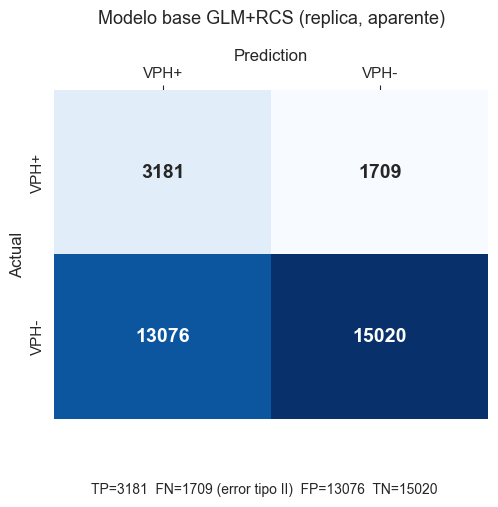

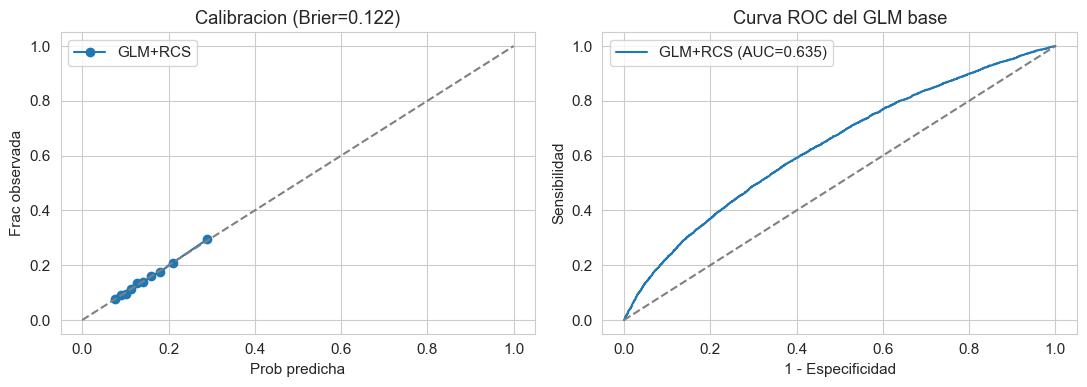

In [7]:
# Metricas de CLASIFICACION del GLM base, SIN modificar el modelo (las que el original no reportaba)
thr_glm0 = find_threshold(y_glm_arr, proba_glm)
print("Modelo base GLM+RCS, metricas de clasificacion aparentes con umbral F1")
print(f"Umbral F1 = {thr_glm0:.4f}")
print(classification_report(y_glm_arr, (proba_glm >= thr_glm0).astype(int), target_names=["VPH-", "VPH+"]))
plot_confusion(y_glm_arr, proba_glm, thr_glm0, "Modelo base GLM+RCS (replica, aparente)")

# Curvas que reporta el estudio de referencia: calibracion y ROC
frac, mean_p = calibration_curve(y_glm_arr, proba_glm, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(mean_p, frac, "o-", label="GLM+RCS"); ax[0].plot([0, 1], [0, 1], "--", color="gray")
ax[0].set_title(f"Calibracion (Brier={brier_ap:.3f})"); ax[0].set_xlabel("Prob predicha"); ax[0].set_ylabel("Frac observada"); ax[0].legend()
fpr, tpr, _ = roc_curve(y_glm_arr, proba_glm)
ax[1].plot(fpr, tpr, label=f"GLM+RCS (AUC={auc_ap:.3f})"); ax[1].plot([0, 1], [0, 1], "--", color="gray")
ax[1].set_xlabel("1 - Especificidad"); ax[1].set_ylabel("Sensibilidad"); ax[1].set_title("Curva ROC del GLM base"); ax[1].legend()
plt.tight_layout(); plt.show()

### Análisis 

Se reproduce el modelo de referencia de forma casi exacta sobre nuestros datos. El subconjunto de casos completos reúne 32.986 pacientes con una prevalencia del 14.8 por ciento, una cifra muy cercana a las 32.914 del archivo original. El AUC aparente asciende a 0.6346 y desciende a 0.6327 al corregir el optimismo, valores prácticamente idénticos al 0.6336 y 0.6311 que reporta el estudio, y el Brier de 0.122 coincide con su 0.121. La corrección por optimismo resulta muy pequeña, de apenas 0.0019, lo que indica que el modelo no está sobreajustado y rendiría parecido en datos nuevos. La eliminación hacia atrás retiene once términos, la edad y el número de hijos como curvas suaves junto con la edad de la primera relación, el número de compañeros sexuales, la procedencia, la etnia, el nivel educativo, el estado conyugal, la menopausia, el antecedente de infección por VPH y el método de planificación hormonal.

Se concluye que el procedimiento se comprende y se reproduce con fidelidad y que la capacidad de discriminación se sitúa en torno a 0.63, cifra que pasa a servir de referencia. Respecto a la clasificación, que el estudio original no medía, con el punto de corte que maximiza el F1 en 0.1345 el modelo base alcanza una sensibilidad de 0.65 frente a una precisión de apenas 0.20 y un F1 de 0.30, y su PR-AUC es de 0.232. Detecta así a dos de cada tres pacientes positivas a costa de marcar a un gran número de negativas. Queda fijado como el rival a batir en las mismas métricas que usarán los modelos que se entrenen en las fases posteriores.


---
# Fase 1: Comprension del Negocio y de los Datos

## Comprensión del Negocio

### Contexto del proyecto

El Centro de Salud Alfonso López, presta servicios de atención primaria en salud a la comunidad. Dentro de estos servicios se encuentra el programa de detección temprana de cáncer de cuello uterino, que incluye la toma de citología cervicouterina por parte del personal de enfermería.

Actualmente, el proceso de citología requiere que la enfermera tome una muestra, la envíe al laboratorio y espere el resultado, lo cual puede tardar días o incluso semanas. Durante ese periodo, la paciente no recibe ninguna estimación sobre su nivel de riesgo de infección por el Virus del Papiloma Humano, que es el principal factor asociado al desarrollo de lesiones precancerosas y cáncer de cuello uterino.

El proyecto propone construir un sistema telemático de apoyo clínico que permita al personal de enfermería estimar el riesgo de infección por VPH directamente en el consultorio, sin depender del resultado del laboratorio, sin embargo este sistema sería de apoyo clínico para contribuir con la priorización e casos y no reemplazaría este resultado de laboratorio. Esta estimación se basa en un modelo predictivo de Machine Learning que utiliza variables clínicas, demográficas y de hábitos de la paciente para calcular una probabilidad de infección.


### Usuario principal

El usuario principal del sistema es el **profesional de enfermería** del Centro de Salud Alfonso López. Este profesional ingresa las variables de la paciente a través de un formulario web, recibe la estimación de riesgo generada por el modelo y consulta las recomendaciones clínicas asociadas al nivel de riesgo calculado.

### Objetivo

El objetivo es contribuir a la **detección temprana del cáncer de cuello uterino**, proporcionando al personal de salud una herramienta que complementa el proceso estándar de citología con una estimación inmediata del riesgo de VPH.



### Formulación del problema de Machine Learning

El problema se formula como una tarea de **clasificación binaria** donde la variable objetivo es `res_vph`, con dos valores posibles.

| Valor | Significado |
|-------|-------------|
| Negativo | La paciente no presenta infección por VPH |
| Positivo | La paciente presenta infección por VPH |

El modelo debe aprender a clasificar el resultado de infección por VPH como Positivo o Negativo a partir de las variables disponibles en el dataset. Estas variables incluyen características demográficas, antecedentes clínicos, hábitos de vida y conocimientos de la paciente sobre el VPH y la citología.

Dado que el propósito clínico consiste en priorizar, esto es, identificar a las pacientes con mayor probabilidad de presentar un resultado positivo de VPH para concentrar en ellas la citología y el seguimiento; dejar sin detectar a una paciente infectada resulta más costoso que generar una alarma de más, aunque las alarmas falsas tampoco son convenientes porque consumen tiempo y recursos del centro de salud. Se busca por tanto un modelo equilibrado, capaz de detectar a la mayoría de las positivas sin inflar los falsos positivos.
## Comprensión de los datos
La exploración avanza de lo general a lo particular. Primero se revisan las dimensiones del conjunto, el tipo de cada columna y un resumen estadístico que da una primera idea de los rangos y las escalas. Después se inspecciona la calidad de los datos, esto es los valores faltantes, las respuestas de tipo no sabe o no responde, los registros duplicados y las inconsistencias de escritura, para saber qué habrá que limpiar o imputar más adelante. Luego se examina la distribución de la variable objetivo, que confirma el desbalance entre positivas y negativas. A continuación se estudia cómo se relaciona cada variable con el resultado de VPH, mediante histogramas y diagramas de caja para las numéricas, la comparación de la edad entre el grupo positivo y el negativo, las tasas de positividad por cada categoría y, por último, unas tablas de contingencia de las variables clave junto con un mapa de correlaciones. Todo ello revela qué variables distinguen mejor a las positivas de las negativas y orienta las decisiones de la fase siguiente.


In [8]:
# Dimensiones, tipos y resumen estadistico
num_features = NUM_COLS
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}\n")
for i, col in enumerate(df.columns):
    print(f"  {i+1:>2}. {col:<40} {str(df[col].dtype)}")
print("\nResumen de variables numericas:")
display = df[NUM_COLS].describe().round(2)
print(display.to_string())
print("\nResumen de variables categoricas:")
print(df[CAT_COLS].describe(include="object").T[["count", "unique", "top", "freq"]].to_string())

Filas: 33174 | Columnas: 31

   1. id                                       int64
   2. procedencia                              object
   3. edad                                     float64
   4. etnia                                    object
   5. nivel_edu_cat                            object
   6. esta_civil_cat                           object
   7. e_conyugal                               object
   8. ocupacion                                object
   9. e_socioecon                              object
  10. edad_primera_menstruacion                float64
  11. edad_primera_relacion_sexual             float64
  12. num_comp_sexuales                        float64
  13. embarazos                                object
  14. n_hijos                                  float64
  15. menopausia                               object
  16. res_citologia_previa                     object
  17. vida_sexual_activa                       object
  18. infeccion_vph_previa                     ob

In [9]:
# Calidad de los datos: faltantes, NS/NR, duplicados e inconsistencias de escritura
missing = df.isnull().sum(); missing_pct = (missing/len(df)*100).round(2)
mdf = pd.DataFrame({"Faltantes": missing, "%": missing_pct})
mdf = mdf[mdf["Faltantes"] > 0].sort_values("Faltantes", ascending=False)
print("Columnas con faltantes:" if len(mdf) else "Sin valores faltantes.")
if len(mdf): print(mdf.to_string())

nsnr = {}
for col in df.select_dtypes(include="object").columns:
    mask = df[col].astype(str).str.strip().str.upper().isin(["NS/NR", "NS", "NR", "NO SABE", "NO RESPONDE", "N/S", "N/R"])
    if mask.sum() > 0: nsnr[col] = int(mask.sum())
print("\nValores NS/NR por columna:", nsnr if nsnr else "ninguno")

print("\nRegistros duplicados:", int(df.duplicated().sum()))

hall = 0
for col in df.select_dtypes(include="object").columns:
    uniques = df[col].dropna().unique()
    groups = {}
    for v in uniques: groups.setdefault(str(v).strip().lower(), []).append(str(v))
    inc = {k: v for k, v in groups.items() if len(v) > 1}
    if inc:
        hall += 1; print(f"  {col} - variantes:", inc)
if hall == 0: print("\nSin inconsistencias de escritura relevantes.")

Columnas con faltantes:
                              Faltantes     %
edad_primera_relacion_sexual         71  0.21
edad                                 59  0.18
edad_primera_menstruacion            40  0.12
num_comp_sexuales                     9  0.03
embarazos                             9  0.03
n_hijos                               9  0.03



Valores NS/NR por columna: {'res_citologia_previa': 11582, 'infeccion_vph_previa': 10285, 'presentado_ets': 9946, 'compañero_trab_sexuales': 19270}

Registros duplicados: 0

Sin inconsistencias de escritura relevantes.


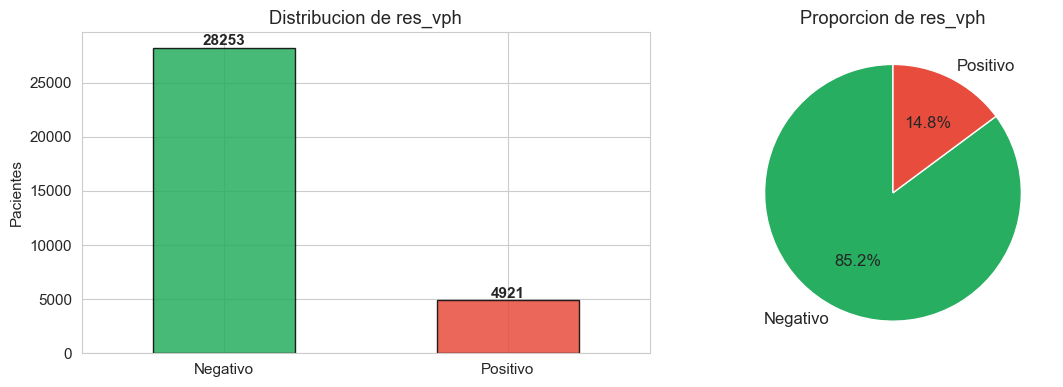

In [10]:
# Distribucion de la variable objetivo res_vph
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#27ae60", "#e74c3c"]
tc = df["res_vph"].value_counts()
tc.plot(kind="bar", ax=axes[0], color=colors, edgecolor="black", alpha=0.85)
axes[0].set_title("Distribucion de res_vph"); axes[0].set_ylabel("Pacientes"); axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(tc.values): axes[0].text(i, v + 200, str(v), ha="center", fontweight="bold")
tc.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", colors=colors, startangle=90, textprops={"fontsize": 12})
axes[1].set_title("Proporcion de res_vph"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

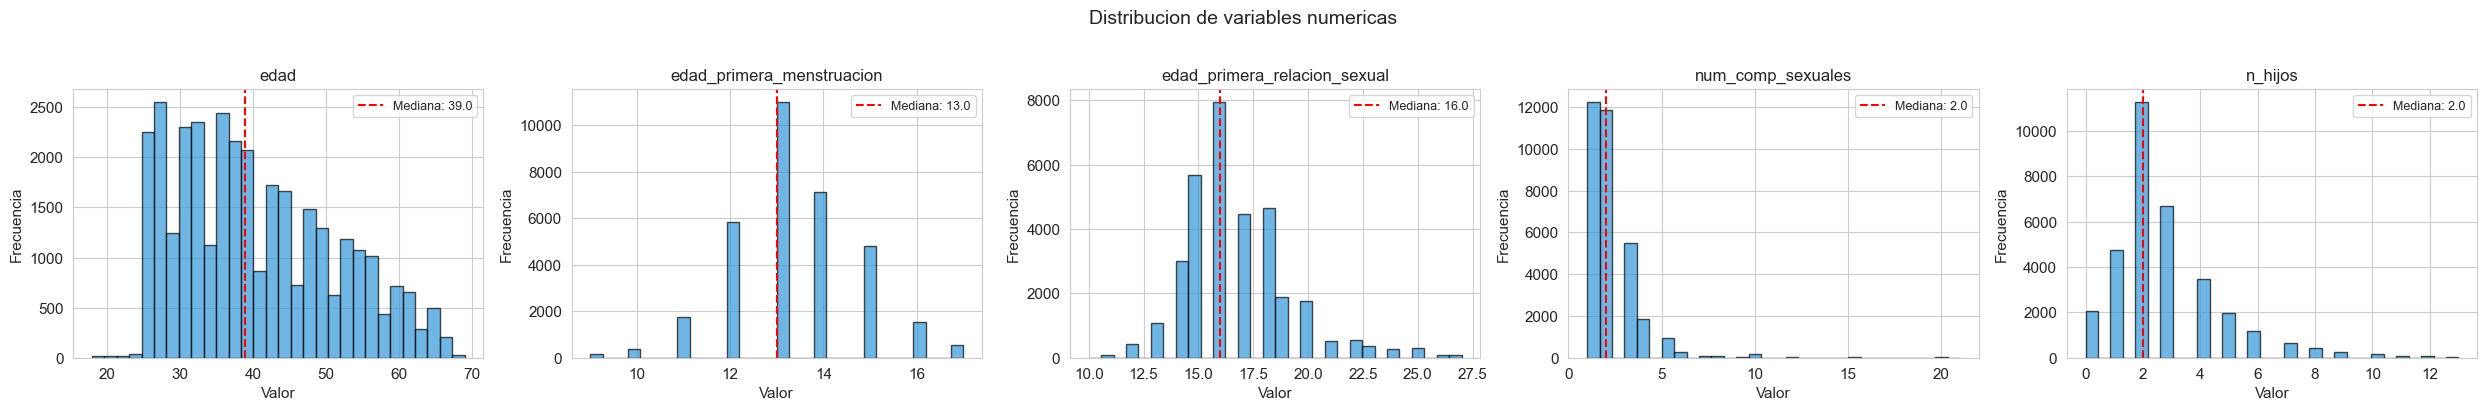

In [11]:
# Distribucion de las variables numericas
num_to_plot = [c for c in NUM_COLS if c in df.columns]
n = len(num_to_plot); fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: axes = [axes]
for ax, col in zip(axes, num_to_plot):
    data = pd.to_numeric(df[col], errors="coerce").dropna()
    ax.hist(data, bins=30, color="#3498db", edgecolor="black", alpha=0.7)
    ax.axvline(data.median(), color="red", linestyle="--", label=f"Mediana: {data.median():.1f}")
    ax.set_title(col, fontsize=12); ax.set_xlabel("Valor"); ax.set_ylabel("Frecuencia"); ax.legend(fontsize=9)
plt.suptitle("Distribucion de variables numericas", fontsize=14, y=1.02); plt.tight_layout(); plt.show()

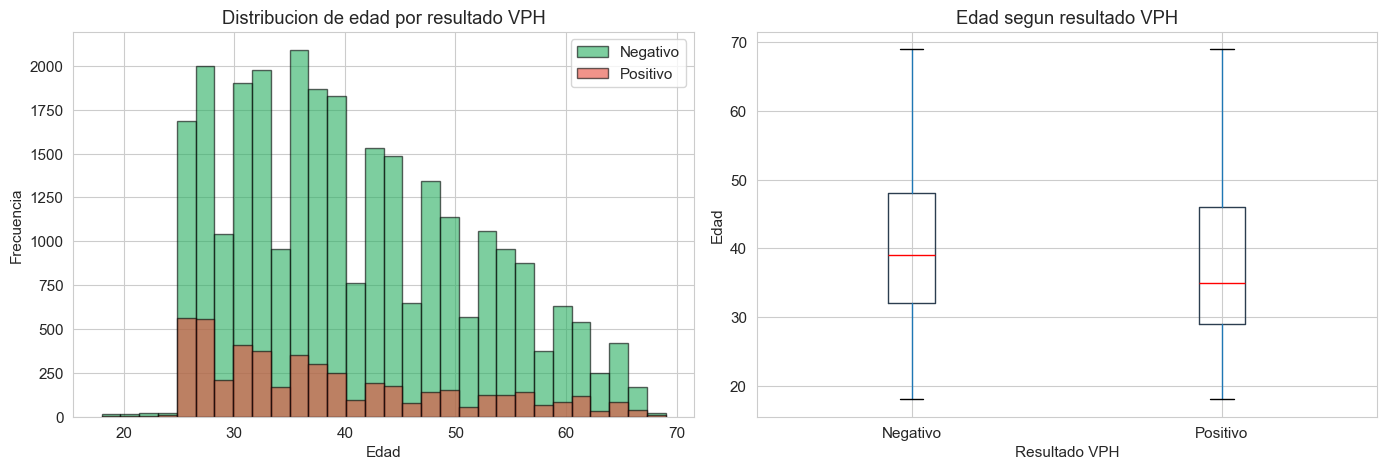


Estadisticas de edad por grupo:
            count  mean   std   min   25%   50%   75%   max
res_vph                                                    
Negativo  28203.0  40.7  10.7  18.0  32.0  39.0  48.0  69.0
Positivo   4912.0  38.4  11.3  18.0  29.0  35.0  46.0  69.0


In [12]:
# Edad segun resultado VPH
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in zip(["Negativo", "Positivo"], ["#27ae60", "#e74c3c"]):
    subset = pd.to_numeric(df[df["res_vph"] == label]["edad"], errors="coerce").dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor="black")
axes[0].set_title("Distribucion de edad por resultado VPH"); axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Frecuencia"); axes[0].legend()
df.boxplot(column="edad", by="res_vph", ax=axes[1], boxprops=dict(color="#2c3e50"), medianprops=dict(color="red"))
axes[1].set_title("Edad segun resultado VPH"); axes[1].set_xlabel("Resultado VPH"); axes[1].set_ylabel("Edad")
plt.suptitle(""); plt.tight_layout(); plt.show()
print("\nEstadisticas de edad por grupo:")
print(df.groupby("res_vph")["edad"].describe().round(1).to_string())

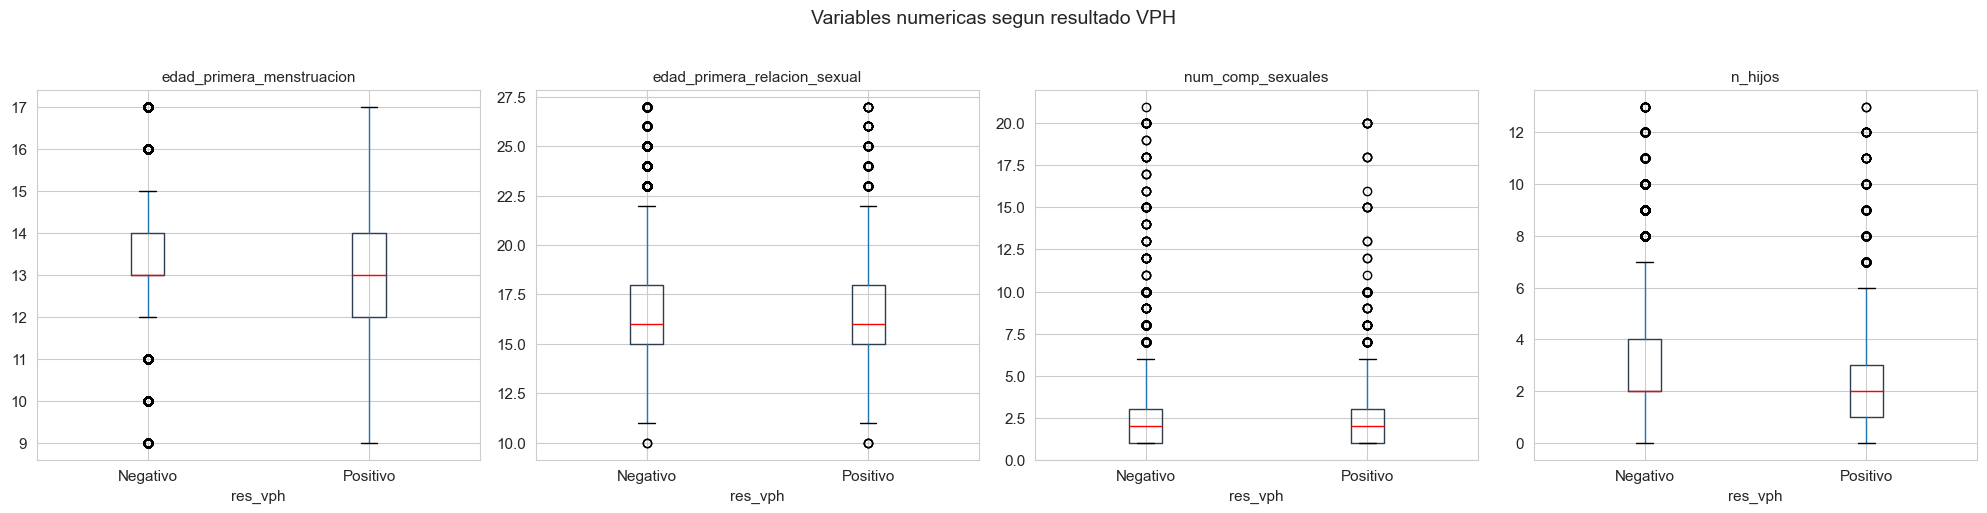

In [13]:
# Boxplots de las demas variables numericas frente al resultado VPH
num_vs = [c for c in ["edad_primera_menstruacion", "edad_primera_relacion_sexual", "num_comp_sexuales", "n_hijos"] if c in df.columns]
n = len(num_vs); fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]
for ax, col in zip(axes, num_vs):
    df.boxplot(column=col, by="res_vph", ax=ax, boxprops=dict(color="#2c3e50"), medianprops=dict(color="red"))
    ax.set_title(col, fontsize=11); ax.set_xlabel("res_vph")
plt.suptitle("Variables numericas segun resultado VPH", fontsize=14, y=1.02); plt.tight_layout(); plt.show()

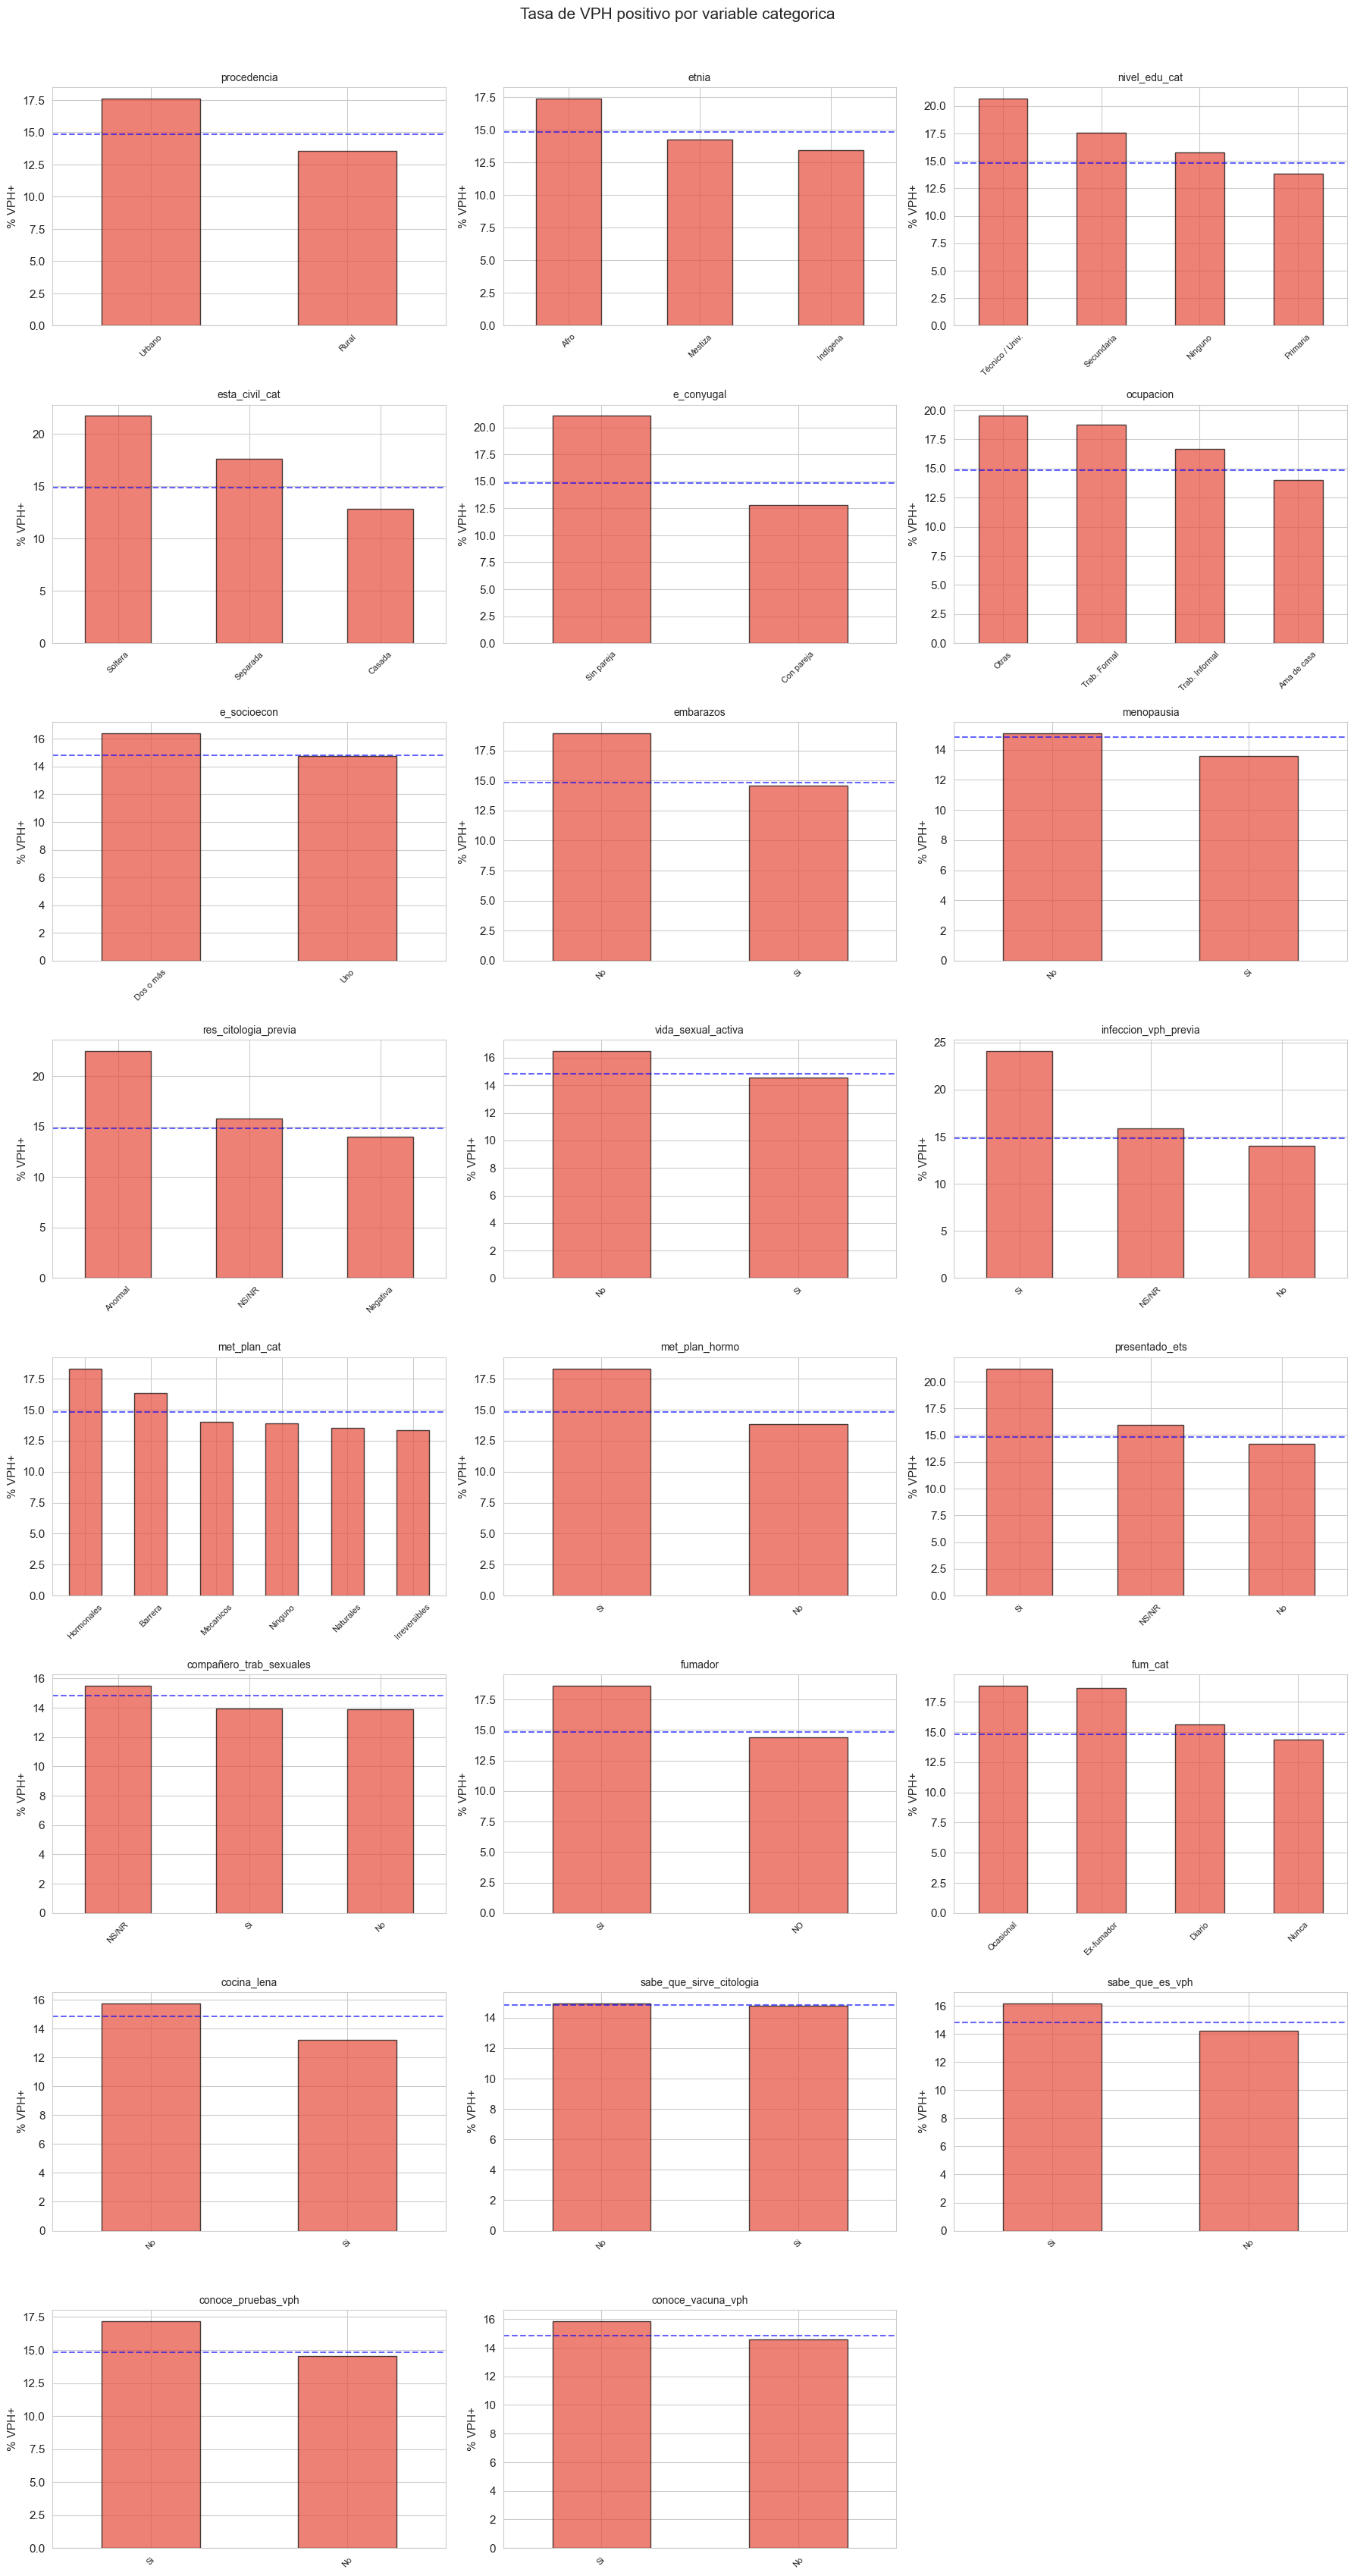

In [14]:
# Tasa de VPH positivo por variable categorica (linea azul = tasa global)
cat_vs = [c for c in CAT_COLS if df[c].nunique(dropna=True) <= 12]
dft = df.copy(); dft["vph"] = (dft["res_vph"] == "Positivo").astype(int)
gr = dft["vph"].mean()*100
n_cols = 3; n_rows = (len(cat_vs) + n_cols - 1)//n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4.2*n_rows))
axf = axes.flatten()
for i, col in enumerate(cat_vs):
    rates = dft.groupby(col)["vph"].mean().sort_values(ascending=False)*100
    rates.plot(kind="bar", ax=axf[i], color="#e74c3c", alpha=0.7, edgecolor="black")
    axf[i].set_title(col, fontsize=10); axf[i].set_ylabel("% VPH+"); axf[i].set_xlabel("")
    axf[i].tick_params(axis="x", rotation=45, labelsize=8)
    axf[i].axhline(y=gr, color="blue", linestyle="--", alpha=0.6)
for j in range(i+1, len(axf)): axf[j].set_visible(False)
plt.suptitle("Tasa de VPH positivo por variable categorica", fontsize=15, y=1.01); plt.tight_layout(); plt.show()


--- procedencia x res_vph (% por fila) ---
res_vph      Negativo  Positivo
procedencia                    
Rural            86.4      13.6
Urbano           82.4      17.6

--- etnia x res_vph (% por fila) ---
res_vph   Negativo  Positivo
etnia                       
Afro          82.6      17.4
Indígena      86.6      13.4
Mestiza       85.8      14.2

--- nivel_edu_cat x res_vph (% por fila) ---
res_vph          Negativo  Positivo
nivel_edu_cat                      
Ninguno              84.3      15.7
Primaria             86.1      13.9
Secundaria           82.5      17.5
Técnico / Univ.      79.3      20.7

--- infeccion_vph_previa x res_vph (% por fila) ---
res_vph               Negativo  Positivo
infeccion_vph_previa                    
NS/NR                     84.1      15.9
No                        86.0      14.0
Si                        75.9      24.1


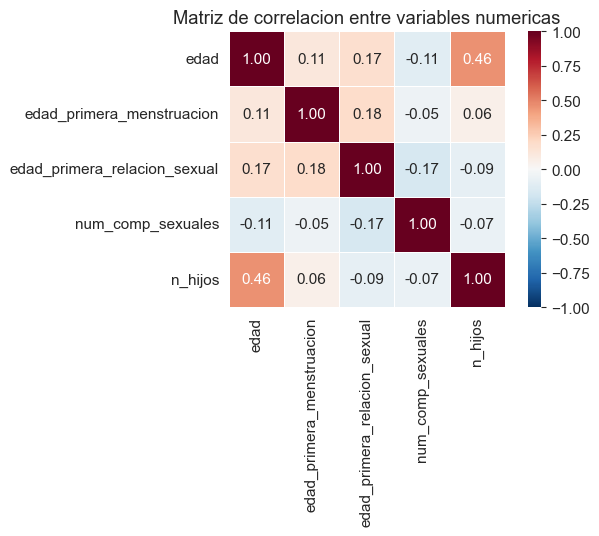

In [15]:
# Tablas de contingencia de algunas variables clave y mapa de correlaciones numericas
key_cats = [c for c in ["procedencia", "etnia", "nivel_edu_cat", "infeccion_vph_previa", "presentado_ets", "sabe_que_es_vph"] if c in df.columns]
for col in key_cats[:4]:
    ct_pct = pd.crosstab(df[col], df["res_vph"], normalize="index").round(4)*100
    print(f"\n--- {col} x res_vph (% por fila) ---")
    print(ct_pct.round(1).to_string())

num_for_corr = [c for c in NUM_COLS if c in df.columns]
corr = df[num_for_corr].apply(pd.to_numeric, errors="coerce").corr().round(2)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, ax=ax, fmt=".2f", linewidths=0.5)
ax.set_title("Matriz de correlacion entre variables numericas"); plt.tight_layout(); plt.show()

### Análisis de la Fase 1

El conjunto reúne 33.174 pacientes con un 14.8 por ciento de positivos, un desbalance fuerte que condiciona todo el desarrollo posterior. La calidad numérica es buena, pues los faltantes no superan el 0.21 por ciento en la edad de la primera relación y son aún menores en el resto. Lo que sí abunda son las respuestas de tipo no sabe o no responde, que llegan a 11.582 registros en el antecedente de citología, 10.285 en el antecedente de VPH, 9.946 en el de infecciones de transmisión sexual y 19.270 en el compañero trabajador sexual. Estas respuestas no se descartan sino que se tratan como una categoría propia durante la imputación, porque el hecho de no saber o no responder puede ser informativo en sí mismo. No se observan duplicados ni inconsistencias de escritura.

La capacidad de las variables para distinguir entre positivas y negativas existe pero es moderada. Las pacientes positivas resultan algo más jóvenes, con una mediana de 35 frente a 39 años y una media de 38.4 frente a 40.7. La tasa de positividad sube en la zona urbana hasta el 17.6 por ciento frente al 13.6 rural, asciende con el nivel educativo hasta el 20.7 por ciento en estudios técnicos o universitarios y, sobre todo, se dispara en quienes refieren un antecedente de infección por VPH, donde alcanza el 24.1 por ciento frente al 14 por ciento de quienes lo niegan. Ninguna variable separa las clases con nitidez por sí sola, lo que anticipa que la capacidad de discriminación que pueda alcnazar el modelo estará limitada. El reto de las fases siguientes será aprovechar al máximo esa capacidad moderada con el mejor tratamiento del desbalance y el mejor modelo.


---
# Fase 2: Ingenieria de Datos

Se prepara la información para modelar. Se separan los datos en entrenamiento y prueba de forma estratificada en una proporción de 70% y 30% respectivamente, conservando la misma fracción de positivos en ambos grupos. No se reserva un tercer grupo de validación porque no se dispone de datos adicionales, así que toda decisión que exige observar resultados, como elegir umbrales o comparar estrategias, se toma mediante validación cruzada fuera de muestra sobre el entrenamiento y se mantienen los datos de prueba intactos hasta la fase final.

El trabajo se ordena en cuatro pasos. Primero se hace la partición estratificada y se bloquea el conjunto de datos de prueba. Después se definen los preprocesamientos por familia de modelo, que comprenden la imputación de faltantes, un indicador que marca dónde faltaba el dato, el escalado para los modelos lineales y la red, y la codificación de las variables categóricas, todo ello ajustado solo con el entrenamiento para no filtrar información. A continuación se muestra a modo de ejemplo cómo SMOTENC genera pacientes positivas sintéticas en el espacio mixto de variables numéricas y categóricas, que es una de las estrategias a evaluar. Por último se ejecuta el estudio de balanceo, en el que sobre un modelo representativo y con validación cruzada se comparan todas las estrategias habituales para el desbalance, desde no aplicar ninguna o ponderar la clase positiva hasta los métodos de sobremuestreo y submuestreo como SMOTE y sus variantes, ADASYN, Tomek, ENN y sus combinaciones. Se selecciona la que mejor equilibra el F1 con un número bajo de falsos positivos y esa misma estrategia se emplea para entrenar a todos los candidatos en la fase siguiente.


In [ ]:
# Particion estratificada 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
X_train = X_train.reset_index(drop=True); X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True); y_test = y_test.reset_index(drop=True)
SPW = float((y_train == 0).sum() / max((y_train == 1).sum(), 1))
print("Train:", X_train.shape, "prev:", round(y_train.mean(), 4),
      "| Test:", X_test.shape, "prev:", round(y_test.mean(), 4), "| scale_pos_weight:", round(SPW, 2))
assert abs(y_train.mean() - y_test.mean()) < 0.01

Train: (23221, 28) prev: 0.1484 | Test: (9953, 28) prev: 0.1483 | scale_pos_weight: 5.74


In [17]:
# ColumnTransformers por familia de modelo (se ajustan solo en train via Pipeline)
pre_lineal = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                      ("sc", RobustScaler())]), NUM_COLS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CAT_COLS),
])
pre_arbol = ColumnTransformer([
    ("num", SimpleImputer(strategy="median", add_indicator=True), NUM_COLS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Missing")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), CAT_COLS),
])
n_feat = clone(pre_lineal).fit_transform(X_train).shape[1]
print("Features tras preprocesamiento (rama lineal):", n_feat,
      "| positivos train:", int(y_train.sum()), "| eventos por feature:", round(int(y_train.sum())/n_feat, 1))

Features tras preprocesamiento (rama lineal): 73 | positivos train: 3445 | eventos por feature: 47.2


In [18]:
# SMOTENC en espacio mixto (num + categoricas ordinal-encoded) que devuelve un DataFrame en columnas originales
from imblearn.over_sampling import (SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN, RandomOverSampler, SMOTENC)
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek

def smotenc_resample(X_tr_df, y_tr, seed=SEED):
    Xc = X_tr_df.copy()
    for c in NUM_COLS: Xc[c] = pd.to_numeric(Xc[c], errors="coerce"); Xc[c] = Xc[c].fillna(Xc[c].median())
    for c in CAT_COLS: Xc[c] = Xc[c].astype("string").fillna("Missing")
    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    Xc[CAT_COLS] = enc.fit_transform(Xc[CAT_COLS])
    cat_idx = [Xc.columns.get_loc(c) for c in CAT_COLS]
    smp = SMOTENC(categorical_features=cat_idx, random_state=seed, k_neighbors=5)
    Xr, yr = smp.fit_resample(Xc.values, np.asarray(y_tr))
    Xr = pd.DataFrame(Xr, columns=Xc.columns)
    Xr[CAT_COLS] = enc.inverse_transform(Xr[CAT_COLS])
    for c in CAT_COLS: Xr[c] = Xr[c].astype("string")
    return Xr, yr

def make_sampler(name):
    if name == "SMOTE":           return SMOTE(random_state=SEED)
    if name == "BorderlineSMOTE": return BorderlineSMOTE(random_state=SEED)
    if name == "SVMSMOTE":        return SVMSMOTE(random_state=SEED)
    if name == "ADASYN":          return ADASYN(random_state=SEED)
    if name == "RandomOver":      return RandomOverSampler(random_state=SEED)
    if name == "RandomUnder":     return RandomUnderSampler(random_state=SEED)
    if name == "TomekLinks":      return TomekLinks()
    if name == "ENN":             return EditedNearestNeighbours()
    if name == "SMOTEENN":        return SMOTEENN(random_state=SEED)
    if name == "SMOTETomek":      return SMOTETomek(random_state=SEED)
    return None

def resample_encoded(Xtr_raw, ytr, pre_f, name):
    """Devuelve (X_encoded, y) listos para entrenar un clf desnudo. La validacion se transforma con el mismo pre_f.
    SMOTENC se enruta por su helper en espacio crudo; el resto operan sobre la matriz ya codificada."""
    ytr = np.asarray(ytr)
    if name in ("sin_balanceo", "class_weight"):
        return pre_f.transform(Xtr_raw), ytr
    if name == "SMOTENC":
        Xr_raw, yr = smotenc_resample(Xtr_raw, ytr)
        return pre_f.transform(Xr_raw), yr
    smp = make_sampler(name)
    return smp.fit_resample(pre_f.transform(Xtr_raw), ytr)

Xr_demo, yr_demo = smotenc_resample(X_train, y_train)
print("SMOTENC demo:", X_train.shape, "->", Xr_demo.shape, "| prev resampleada:", round(np.mean(yr_demo), 3))

SMOTENC demo: (23221, 28) -> (39552, 28) | prev resampleada: 0.5


In [19]:
# Estudio de balanceo: todas las estrategias sobre un modelo representativo (HistGB), validacion cruzada OOF.
# Se ordena por F1 y luego por menor numero de falsos positivos (criterio de seleccion del proyecto).
ESTRATEGIAS = ["sin_balanceo", "class_weight", "SMOTE", "BorderlineSMOTE", "SVMSMOTE", "ADASYN",
               "RandomOver", "RandomUnder", "TomekLinks", "ENN", "SMOTEENN", "SMOTETomek", "SMOTENC"]

def oof_balanceo(name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y_train)); yv = y_train.values
    for tr, va in cv.split(X_train, yv):
        Xtr_raw, ytr = X_train.iloc[tr], yv[tr]
        pre_f = clone(pre_arbol); pre_f.fit(Xtr_raw)
        Xr, yr = resample_encoded(Xtr_raw, ytr, pre_f, name)
        cw = "balanced" if name == "class_weight" else None
        clf = HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                              random_state=SEED, class_weight=cw)
        clf.fit(Xr, yr)
        oof[va] = clf.predict_proba(pre_f.transform(X_train.iloc[va]))[:, 1]
    return oof

filas_bal = []
yv = y_train.values
for name in ESTRATEGIAS:
    try:
        oof = oof_balanceo(name)
        thr = find_threshold(yv, oof)
        m = fila_metricas(name, yv, oof, thr); m["PRAUC"] = average_precision_score(yv, oof)
        filas_bal.append(m)
        print(f"{name:16s} F1={m['F1']:.4f} FP={m['FP']:4d} FN={m['FN']:4d} Recall={m['Recall']:.3f} PRAUC={m['PRAUC']:.4f}")
    except Exception as e:
        print(f"{name:16s} FALLO: {type(e).__name__} {str(e)[:90]}")
tab_bal = pd.DataFrame(filas_bal)[["modelo", "F1", "FP", "FN", "Recall", "Precision", "PRAUC", "MCC"]]
tab_bal = tab_bal.sort_values(["F1", "FP"], ascending=[False, True]).reset_index(drop=True)
print("\nEstudio de balanceo con HistGB sobre OOF, ordenado por F1 y luego menor FP")
print(tab_bal.round(4).to_string(index=False))
SAMPLER_WIN = tab_bal.iloc[0]["modelo"]
print("\nEstrategia de balanceo ganadora:", SAMPLER_WIN)

sin_balanceo     F1=0.3048 FP=9046 FN=1199 Recall=0.652 PRAUC=0.2334


class_weight     F1=0.3019 FP=9223 FN=1193 Recall=0.654 PRAUC=0.2313


SMOTE            F1=0.2941 FP=9550 FN=1205 Recall=0.650 PRAUC=0.2238


BorderlineSMOTE  F1=0.2947 FP=9579 FN=1194 Recall=0.653 PRAUC=0.2234


SVMSMOTE         F1=0.2941 FP=9633 FN=1190 Recall=0.655 PRAUC=0.2237


...

TomekLinks       F1=0.3017 FP=9358 FN=1171 Recall=0.660 PRAUC=0.2356


ENN              F1=0.3013 FP=9266 FN=1190 Recall=0.655 PRAUC=0.2313


SMOTEENN         F1=0.2994 FP=9442 FN=1176 Recall=0.659 PRAUC=0.2305


SMOTETomek       F1=0.2924 FP=9749 FN=1186 Recall=0.656 PRAUC=0.2226


SMOTENC          F1=0.2770 FP=10490 FN=1205 Recall=0.650 PRAUC=0.2060

Estudio de balanceo con HistGB sobre OOF, ordenado por F1 y luego menor FP
         modelo     F1    FP   FN  Recall  Precision  PRAUC    MCC
   sin_balanceo 0.3048  9046 1199  0.6520     0.1989 0.2334 0.1383
   class_weight 0.3019  9223 1193  0.6537     0.1963 0.2313 0.1332
     TomekLinks 0.3017  9358 1171  0.6601     0.1955 0.2356 0.1329
            ENN 0.3013  9266 1190  0.6546     0.1957 0.2313 0.1322
     RandomOver 0.3000  9270 1201  0.6514     0.1949 0.2282 0.1298
       SMOTEENN 0.2994  9442 1176  0.6586     0.1937 0.2305 0.1288
    RandomUnder 0.2971  9393 1205  0.6502     0.1926 0.2227 0.1246
BorderlineSMOTE 0.2947  9579 1194  0.6534     0.1903 0.2234 0.1202
       SVMSMOTE 0.2941  9633 1190  0.6546     0.1897 0.2237 0.1191
         ADASYN 0.2941  9629 1191  0.6543     0.1897 0.2264 0.1190
          SMOTE 0.2941  9550 1205  0.6502     0.1900 0.2238 0.1190
     SMOTETomek 0.2924  9749 1186  0.6557     0.18

### Análisis de la Fase 2

La partición deja 23.221 pacientes para entrenar y 9.953 para la prueba, ambas con un 14.8 por ciento de positivos, y el desbalance equivale a una clase negativa 5.74 veces más numerosa que la positiva. Tras el preprocesamiento la rama lineal queda con 73 columnas y 3.445 positivos en el entrenamiento, lo que da unos 47 eventos por columna, un margen cómodo que aleja el riesgo de sobreajuste. 

El estudio de balanceo arroja un resultado claro y a la vez revelador, ninguna estrategia de remuestreo mejora al hecho de no balancear. Las trece estrategias quedan muy juntas con un F1 comprendido entre 0.277 y 0.305, y la que mejor equilibra el F1 con el menor número de falsos positivos es no aplicar balanceo, que alcanza un F1 de 0.305 con 9.046 falsos positivos, el conteo más bajo de todos, y el mejor coeficiente de correlación de Matthews con 0.138. La ponderación de clase queda muy cerca con un F1 de 0.302, mientras que todas las técnicas de sobremuestreo sintético como SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN y sus combinaciones empeoran el resultado al inflar los falsos positivos sin ganar sensibilidad útil, y SMOTENC es la peor de todas con un F1 de 0.277 y 10.490 falsos positivos, porque genera categorías sintéticas poco realistas.

Se interpreta que, cuando las variables distinguen poco a las dos clases, fabricar positivas artificiales solo añade ruido, de modo que conviene dejar los datos como están y gestionar el desbalance mediante la calibración de probabilidades y el ajuste del umbral, que es precisamente lo que hace el criterio del F1 con piso de sensibilidad. Guiados por estos resultados se adopta la ausencia de balanceo para entrenar a todos los candidatos en la Fase 3. 


---
# Fase 3: Ingenieria del Modelo 

Se entrena un conjunto de modelos candidatos y se elige al ganador. Cada modelo de aprendizaje automático se entrena con la estrategia de balanceo ganadora de la fase anterior y sus probabilidades se calibran mediante regresión isotónica para que el porcentaje de riesgo resulte fiable. A cada candidato se le fija el umbral que maximiza su F1 con un piso de sensibilidad, todo ello mediante validación cruzada fuera de muestra sobre el entrenamiento y sin tocar la prueba.

La fase se construye en varios pasos. Primero se definen los estimadores de cada modelo con sus preprocesamientos. Después se entrena la red neuronal, a la que se le repite la comparación de estrategias de desbalance para escoger la suya propia. A continuación se generan las probabilidades fuera de muestra de los seis modelos clásicos ya calibrados y se calcula el umbral de F1 de cada uno. Luego se suma el modelo base GLM, que también compite con sus probabilidades fuera de muestra sobre los casos completos. Por último se arma la tabla de comparación, que ordena a todos los modelos por su resultado de F1-score y reporta la matriz de confusión completa de cada uno al umbral que le corresponde. Compiten así en igualdad de condiciones la regresión logística, el bosque aleatorio, el gradiente potenciado en sus variantes HistGB, LightGBM, XGBoost y CatBoost, la red neuronal y el modelo base. El mejor modelo se decide por el mayor F1-score y, ante el empate estadístico que se observa entre casi todos, se elige al que presenta la menor tasa de falsos positivos y, en último término, el mejor coeficiente de correlación de Matthews.


In [20]:
# Estimadores por modelo. config "B" activa la ponderacion de clase (cuando la estrategia ganadora es class_weight).
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

def construir(modelo, config="A"):
    bal = (config == "B")
    if modelo == "LogReg":
        return Pipeline([("pre", clone(pre_lineal)),
                         ("clf", LogisticRegression(max_iter=2000, class_weight=("balanced" if bal else None)))])
    if modelo == "RandomForest":
        return Pipeline([("pre", clone(pre_arbol)),
                         ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, n_jobs=NJ, random_state=SEED,
                                                        class_weight=("balanced" if bal else None)))])
    if modelo == "HistGB":
        return Pipeline([("pre", clone(pre_arbol)),
                         ("clf", HistGradientBoostingClassifier(max_iter=300, max_depth=4, learning_rate=0.05,
                                                                random_state=SEED,
                                                                class_weight=("balanced" if bal else None)))])
    if modelo == "LightGBM":
        return Pipeline([("pre", clone(pre_arbol)),
                         ("clf", LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED,
                                                n_jobs=NJ, verbosity=-1, class_weight=("balanced" if bal else None)))])
    if modelo == "XGBoost":
        return Pipeline([("pre", clone(pre_arbol)),
                         ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=SEED,
                                               n_jobs=NJ, eval_metric="logloss", verbosity=0,
                                               scale_pos_weight=(SPW if bal else 1.0)))])
    if modelo == "CatBoost":
        return Pipeline([("pre", clone(pre_arbol)),
                         ("clf", CatBoostClassifier(iterations=300, depth=4, learning_rate=0.05, random_seed=SEED,
                                                    thread_count=NJ, verbose=0,
                                                    class_weights=([1, SPW] if bal else None)))])
    raise ValueError(modelo)

CANDIDATOS = ["LogReg", "RandomForest", "HistGB", "LightGBM", "XGBoost", "CatBoost"]
print("construir() listo. Candidatos:", CANDIDATOS)

construir() listo. Candidatos: ['LogReg', 'RandomForest', 'HistGB', 'LightGBM', 'XGBoost', 'CatBoost']


In [21]:
# Red neuronal: se prueba que forma de manejar el desbalance funciona mejor y se entrena la arquitectura elegida.
# El umbral (F1) y la calibracion se fijan en una particion interna de validacion para no mirar el test.
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split as _tts

KARCH = [64, 32, 16]; KDROP = 0.3; KLR = 1e-3; KEPOCHS = 150; KPAT = 15; KCWMULT = 1.5

def _build_keras(d, arch=KARCH, dropout=KDROP, lr=KLR):
    keras.utils.set_random_seed(SEED)
    m = keras.Sequential([keras.layers.Input(shape=(d,))])
    for u in arch:
        m.add(keras.layers.Dense(u, activation="relu"))
        m.add(keras.layers.BatchNormalization()); m.add(keras.layers.Dropout(dropout))
    m.add(keras.layers.Dense(1, activation="sigmoid"))
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="binary_crossentropy", metrics=["AUC"])
    return m

def _fit_red(Xraw, yraw, config, pre):
    pre.fit(Xraw)
    if config == "C":
        Xr, yr = smotenc_resample(Xraw, yraw)
    else:
        Xr, yr = Xraw, yraw
    Xm = pre.transform(Xr)
    cw = {0: 1.0, 1: float((yr == 0).sum()/max((yr == 1).sum(), 1)) * KCWMULT} if config == "B" else None
    es = keras.callbacks.EarlyStopping(monitor="val_AUC", mode="max", patience=KPAT, restore_best_weights=True)
    mdl = _build_keras(Xm.shape[1])
    yv = yr.values if hasattr(yr, "values") else yr
    mdl.fit(Xm, yv, validation_split=0.15, epochs=KEPOCHS, batch_size=256, verbose=0, class_weight=cw, callbacks=[es])
    return mdl

Xtr_i, Xho_i, ytr_i, yho_i = _tts(X_train, y_train, test_size=0.2, stratify=y_train, random_state=SEED)
y_ho_k = yho_i.values
comp_red = []
for cfg in ["A", "B", "C"]:
    pre_c = clone(pre_lineal); mdl_c = _fit_red(Xtr_i, ytr_i, cfg, pre_c)
    p_c = mdl_c.predict(pre_c.transform(Xho_i), verbose=0).ravel()
    iso_c = IsotonicRegression(out_of_bounds="clip").fit(p_c, y_ho_k)
    pc_c = iso_c.predict(p_c)
    th_c = find_threshold(y_ho_k, pc_c); met_c = evaluate_model(y_ho_k, pc_c, th_c)
    comp_red.append((cfg, met_c["F1"], met_c["Recall"]))
    print(f"Red estrategia {cfg}: F1={met_c['F1']:.4f}  Recall={met_c['Recall']:.4f}  FP={met_c['FP']}")
KCONFIG = max(comp_red, key=lambda r: r[1])[0]
print("Estrategia de desbalance elegida para la red:", KCONFIG)

pre_keras = clone(pre_lineal); model_keras = _fit_red(Xtr_i, ytr_i, KCONFIG, pre_keras)
proba_ho_k = model_keras.predict(pre_keras.transform(Xho_i), verbose=0).ravel()
iso_keras = IsotonicRegression(out_of_bounds="clip").fit(proba_ho_k, y_ho_k)
proba_ho_k_cal = iso_keras.predict(proba_ho_k)
thr_keras = find_threshold(y_ho_k, proba_ho_k_cal)
print(f"Red final ({KCONFIG}): umbral F1={thr_keras:.4f}  AP={average_precision_score(y_ho_k, proba_ho_k_cal):.4f}")

Red estrategia A: F1=0.2888  Recall=0.8229  FP=2671


Red estrategia B: F1=0.2959  Recall=0.7533  FP=2300


Red estrategia C: F1=0.2623  Recall=0.7402  FP=2690
Estrategia de desbalance elegida para la red: B


Red final (B): umbral F1=0.1357  AP=0.2326


In [22]:
# Cada candidato se entrena con la estrategia de balanceo ganadora, en validacion cruzada OOF,
# y sus probabilidades OOF se calibran (isotonica) para fijar el umbral F1 sin fuga de informacion.
def _clf_for(m):
    return clone(construir(m, "B" if SAMPLER_WIN == "class_weight" else "A").named_steps["clf"])
def _pre_for(m):
    return clone(pre_lineal if m == "LogReg" else pre_arbol)

def oof_cal_sampler(m):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof = np.zeros(len(y_train)); yv = y_train.values
    for tr, va in cv.split(X_train, yv):
        Xtr, ytr = X_train.iloc[tr], yv[tr]
        pre_f = _pre_for(m); pre_f.fit(Xtr)
        Xr, yr = resample_encoded(Xtr, ytr, pre_f, SAMPLER_WIN)
        clf = _clf_for(m); clf.fit(Xr, yr)
        oof[va] = clf.predict_proba(pre_f.transform(X_train.iloc[va]))[:, 1]
    iso = IsotonicRegression(out_of_bounds="clip").fit(oof, yv)
    return iso.predict(oof), iso

oof_cal = {}; thr_cand = {}; iso_cand = {}
for m in CANDIDATOS:
    oc, iso = oof_cal_sampler(m); oof_cal[m] = oc; iso_cand[m] = iso
    thr_cand[m] = find_threshold(y_train.values, oc)
    print(f"{m:14s} F1-umbral(OOF)={thr_cand[m]:.4f}  AP={average_precision_score(y_train.values, oc):.4f}")

LogReg         F1-umbral(OOF)=0.1332  AP=0.2237


RandomForest   F1-umbral(OOF)=0.1397  AP=0.2286


HistGB         F1-umbral(OOF)=0.1303  AP=0.2309


LightGBM       F1-umbral(OOF)=0.1299  AP=0.2272


XGBoost        F1-umbral(OOF)=0.1377  AP=0.2268


CatBoost       F1-umbral(OOF)=0.1289  AP=0.2349


In [23]:
# El modelo base GLM tambien compite: su probabilidad OOF sobre los casos completos del entrenamiento.
glm_cols = [c for c in df_glm.columns if c != "res_vph"]
df_tr_glm = X_train[glm_cols].copy()
for c in [v for v in glm_cols if v in CAT_COLS]:
    df_tr_glm[c] = df_tr_glm[c].astype("string")
df_tr_glm["res_vph"] = y_train.values
mask_tr = df_tr_glm.notna().all(axis=1).values
dfg = df_tr_glm[mask_tr].reset_index(drop=True)
yg = dfg["res_vph"].values.astype(int)
oof_glm = np.zeros(len(dfg))
cvg = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for tr, va in cvg.split(dfg, yg):
    yt, Xt = dmatrices(formula_final, data=dfg.iloc[tr], return_type="dataframe")
    g = sm.GLM(yt, Xt, family=sm.families.Binomial()).fit()
    Xv = build_design_matrices([Xt.design_info], dfg.iloc[va])[0]
    oof_glm[va] = np.asarray(g.predict(np.asarray(Xv)))
thr_glm_oof = find_threshold(yg, oof_glm)
print(f"GLM_base  F1-umbral(OOF)={thr_glm_oof:.4f}  AP={average_precision_score(yg, oof_glm):.4f}  (n casos completos={len(yg)})")

GLM_base  F1-umbral(OOF)=0.1322  AP=0.2312  (n casos completos=23078)


Coronacion: F1 como criterio primario (tabla ordenada por F1)
      modelo     F1     F2  Recall  Precision    FP   FN   TP    TN  FP_rate    MCC  BalAcc  umbral
RandomForest 0.3045 0.4519  0.6671     0.1973  9350 1147 2298 10426   0.4728 0.1381  0.5971  0.1397
      HistGB 0.3044 0.4494  0.6583     0.1980  9188 1177 2268 10588   0.4646 0.1377  0.5969  0.1303
    GLM_base 0.3022 0.4486  0.6626     0.1957  9312 1154 2266 10346   0.4737 0.1342  0.5944  0.1322
     XGBoost 0.3004 0.4536  0.6871     0.1923  9945 1078 2367  9831   0.5029 0.1312  0.5921  0.1377
    LightGBM 0.3002 0.4530  0.6859     0.1921  9937 1082 2363  9839   0.5025 0.1306  0.5917  0.1299
    CatBoost 0.3001 0.4608  0.7164     0.1898 10534  977 2468  9242   0.5327 0.1316  0.5919  0.1289
      LogReg 0.2987 0.4471  0.6682     0.1924  9664 1143 2302 10112   0.4887 0.1277  0.5898  0.1332
    RedKeras 0.2959 0.4655  0.7533     0.1841  2300  170  519  1656   0.5814 0.1251  0.5859  0.1357


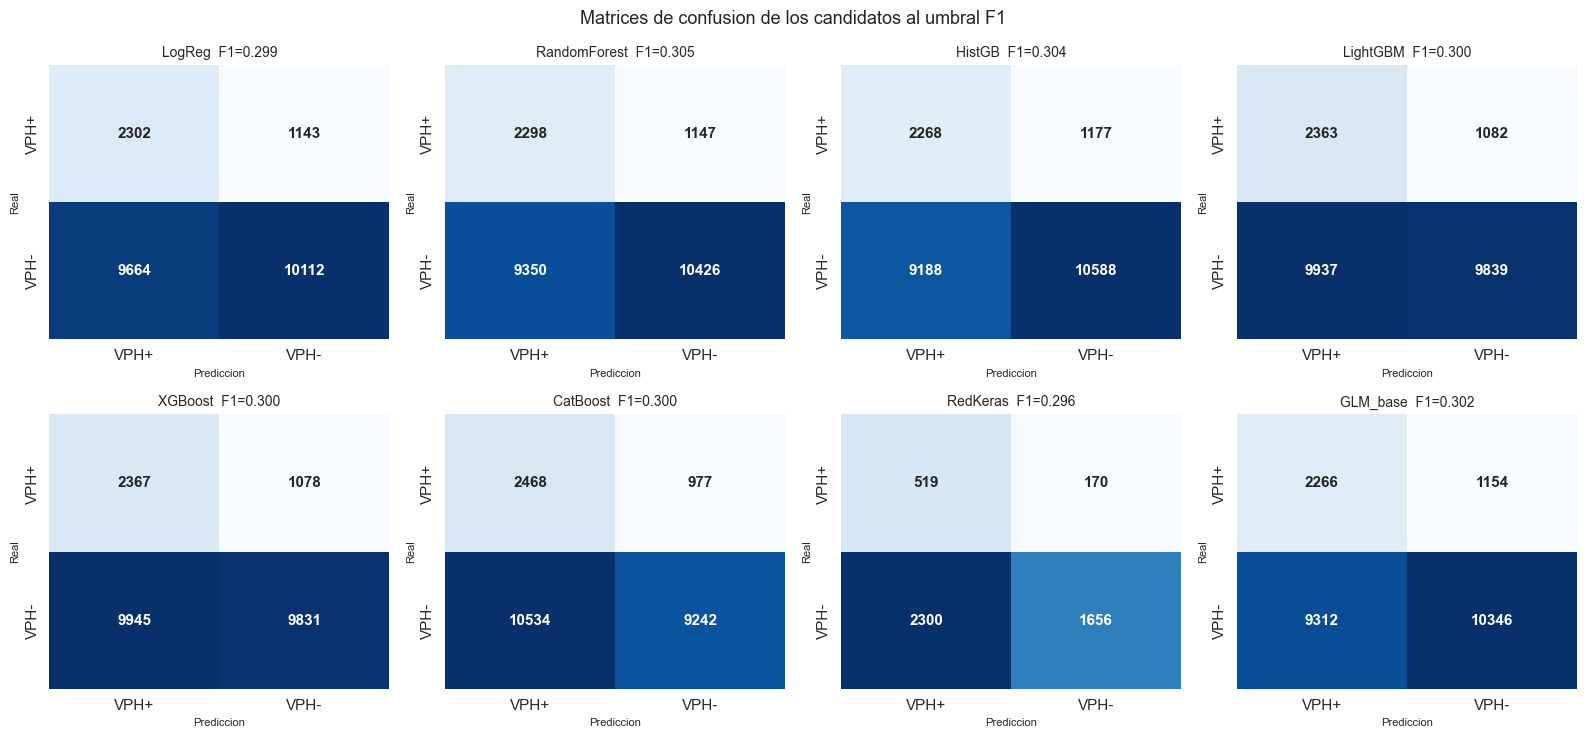


Empate estadistico en F1 (a <0.005 del maximo 0.3045): ['HistGB', 'RandomForest', 'GLM_base', 'LightGBM', 'XGBoost', 'CatBoost']
Se corona al de menor tasa de falsos positivos dentro de ese grupo.

CAMPEON: HistGB  (sklearn)  umbral(F1)=0.1303


In [ ]:
# Tabla de comparación por F1 (desempate: menor FP, luego MCC). Incluye la red Keras y el GLM base.
filas = [fila_metricas(m, y_train.values, oof_cal[m], thr_cand[m]) for m in CANDIDATOS]
filas.append(fila_metricas("RedKeras", y_ho_k, proba_ho_k_cal, thr_keras))
filas.append(fila_metricas("GLM_base", yg, oof_glm, thr_glm_oof))
tabla = pd.DataFrame(filas)
# Tasa de falsos positivos (FP/(FP+TN)): invariante al tamano del conjunto, asi el desempate por FP
# es justo aunque la red Keras se evalue en un holdout mas pequeno que el OOF de los demas.
tabla["FP_rate"] = tabla["FP"] / (tabla["FP"] + tabla["TN"])
tabla = tabla[["modelo", "F1", "F2", "Recall", "Precision", "FP", "FN", "TP", "TN", "FP_rate", "MCC", "BalAcc", "umbral"]]
tabla = tabla.sort_values(["F1", "FP_rate"], ascending=[False, True]).reset_index(drop=True)
print("Comparación: F1 como criterio primario (tabla ordenada por F1)")
print(tabla.round(4).to_string(index=False))
for _, r in tabla.iterrows():
    tme_add("F3_corona", r["modelo"], "ganador_balanceo", F1=r["F1"], Recall=r["Recall"],
            Precision=r["Precision"], FP=int(r["FP"]), FN=int(r["FN"]), MCC=r["MCC"])

# Matriz de confusion de cada candidato al umbral F1 que le corresponde
modelos_cm = [(m, y_train.values, oof_cal[m], thr_cand[m]) for m in CANDIDATOS]
modelos_cm.append(("RedKeras", y_ho_k, proba_ho_k_cal, thr_keras))
modelos_cm.append(("GLM_base", yg, oof_glm, thr_glm_oof))
fig, axes = plt.subplots(2, 4, figsize=(16, 7.5)); axf = axes.ravel()
for ax, (nom, yy, pp, th) in zip(axf, modelos_cm):
    cm_on_ax(ax, yy, pp, th, f"{nom}  F1={evaluate_model(yy, pp, th)['F1']:.3f}")
for ax in axf[len(modelos_cm):]: ax.axis("off")
plt.suptitle("Matrices de confusion de los candidatos al umbral F1", fontsize=13)
plt.tight_layout(); plt.show()

# Comparación
# (empate estadistico), se elige el de MENOR TASA DE FALSOS POSITIVOS, luego mayor MCC.
f1max = tabla["F1"].max()
cluster = tabla[tabla["F1"] >= f1max - 0.005].copy().sort_values(["FP_rate", "MCC"], ascending=[True, False])
print(f"\nEmpate estadistico en F1 (a <0.005 del maximo {f1max:.4f}): {list(cluster['modelo'])}")
print("Se elige al de menor tasa de falsos positivos dentro de ese grupo.")
CAMPEON = cluster.iloc[0]["modelo"]
if CAMPEON == "RedKeras":   UMBRAL_CAMPEON = float(thr_keras); TIPO_CAMPEON = "keras"
elif CAMPEON == "GLM_base": UMBRAL_CAMPEON = float(thr_glm_oof); TIPO_CAMPEON = "glm"
else:                       UMBRAL_CAMPEON = float(thr_cand[CAMPEON]); TIPO_CAMPEON = "sklearn"
print(f"\nCAMPEON: {CAMPEON}  ({TIPO_CAMPEON})  umbral(F1)={UMBRAL_CAMPEON:.4f}")

### Análisis de la Fase 3

Los ocho candidatos terminan prácticamente empatados, con un F1-score que va de 0.296 a 0.305, una diferencia que cae dentro del ruido estadístico. El bosque aleatorio y el gradiente potenciado HistGB comparten el primer puesto con 0.3045 frente a 0.3044, apenas una milésima, de modo que decidir sólamente por el F1-score resultaría arbitrario. Seis modelos quedan a menos de cinco milésimas del máximo y forman el grupo de empate. Aplicando el criterio del proyecto, que entre modelos de F1-score equivalente prefiere al de menos falsos positivos, se elige a HistGB, que con idéntico F1 logra la menor tasa de falsos positivos del grupo, 0.465 frente al 0.473 del RandomForest, además de un PR-AUC de 0.231.

El desempate se realiza sobre la tasa de falsos positivos, ya que la red neuronal se evalúa en una partición interna más pequeña y comparar conteos la favorecería de forma engañosa. De hecho la red marca a muy pocas pacientes en términos absolutos, con solo 2.300 falsos positivos, pero su tasa de falsos positivos es la peor del grupo, 0.581, pese a su elevada sensibilidad de 0.753, y su F1 de 0.296 la deja fuera del empate. Más relevante todavía es que el modelo base GLM se sitúa en el centro del grupo con un F1 de 0.302, lo que adelanta que los modelos de aprendizaje automático no consiguen separarse de la referencia. 


---
# Fase 4 : Evaluacion del Modelo

Se aborda por fin el conjunto de prueba, que el modelo nunca vio. Con el ganador ya congelado se recorre la evaluación en cinco pasos. Primero se obtiene la probabilidad del campeón sobre la prueba en una sola pasada y se calculan el PR-AUC, el AUC ROC y el Brier acompañados de sus intervalos de confianza por bootstrap. Después se reporta la matriz de confusión y el informe de clasificación al umbral elegido, junto con las curvas de precisión y sensibilidad, ROC y calibración. A continuación se valora la utilidad clínica mediante el análisis de curva de decisión, que cuantifica el beneficio neto de usar el modelo frente a las alternativas de citar a todas o no citar a ninguna. Luego se examina la equidad por grupos de edad, con la sensibilidad y la matriz de confusión de cada grupo, y se desglosan los falsos negativos y los falsos positivos. Por último se compara al campeón cara a cara con el modelo base sobre las mismas pacientes y en las mismas métricas. Con todo ello se emite una conclusión honesta sobre el techo de rendimiento que imponen los datos disponibles junto con la decisión de uso.


In [25]:
# Se congela el ganador y se obtiene su probabilidad sobre el test en una sola pasada (rama segun el tipo)
if TIPO_CAMPEON == "keras":
    pre_fin = clone(pre_lineal); ARTEFACTO = _fit_red(X_train, y_train, KCONFIG, pre_fin)
    proba_test = iso_keras.predict(ARTEFACTO.predict(pre_fin.transform(X_test), verbose=0).ravel())
elif TIPO_CAMPEON == "glm":
    yt, Xt = dmatrices(formula_final, data=dfg, return_type="dataframe")
    ARTEFACTO = sm.GLM(yt, Xt, family=sm.families.Binomial()).fit()
    dte = X_test[glm_cols].copy()
    for c in [v for v in glm_cols if v in CAT_COLS]: dte[c] = dte[c].astype("string")
    mask_te = dte.notna().all(axis=1).values
    proba_test = np.full(len(X_test), np.nan)
    Xte = build_design_matrices([Xt.design_info], dte[mask_te].reset_index(drop=True))[0]
    proba_test[mask_te] = np.asarray(ARTEFACTO.predict(np.asarray(Xte)))
    GLM_DESIGN = Xt.design_info
else:
    pre_full = _pre_for(CAMPEON); pre_full.fit(X_train)
    Xr, yr = resample_encoded(X_train, y_train, pre_full, SAMPLER_WIN)
    clf_full = _clf_for(CAMPEON); clf_full.fit(Xr, yr)
    iso_full = iso_cand[CAMPEON]
    proba_test = iso_full.predict(clf_full.predict_proba(pre_full.transform(X_test))[:, 1])
    ARTEFACTO = {"pre": pre_full, "clf": clf_full, "iso": iso_full}

_m = ~np.isnan(proba_test)
yte = y_test.values[_m]; pte = proba_test[_m]
prauc_te = average_precision_score(yte, pte); roc_te = roc_auc_score(yte, pte); brier_te = brier_score_loss(yte, pte)
prauc_ci = bootstrap_ic(yte, pte, average_precision_score); roc_ci = bootstrap_ic(yte, pte, roc_auc_score)
print(f"GANADOR={CAMPEON} ({TIPO_CAMPEON})  umbral={UMBRAL_CAMPEON:.4f}  n_test={len(yte)}")
print(f"TEST PR-AUC={prauc_te:.4f} IC95{tuple(round(x,4) for x in prauc_ci[1:])}  "
      f"ROC={roc_te:.4f} IC95{tuple(round(x,4) for x in roc_ci[1:])}  Brier={brier_te:.4f}  piso(prev)={yte.mean():.4f}")

GANADOR=HistGB (sklearn)  umbral=0.1303  n_test=9953
TEST PR-AUC=0.2258 IC95(0.2103, 0.2434)  ROC=0.6287 IC95(0.6129, 0.6449)  Brier=0.1226  piso(prev)=0.1483


              precision    recall  f1-score   support

        VPH-       0.90      0.55      0.68      8477
        VPH+       0.20      0.64      0.30      1476

    accuracy                           0.56      9953
   macro avg       0.55      0.60      0.49      9953
weighted avg       0.79      0.56      0.63      9953



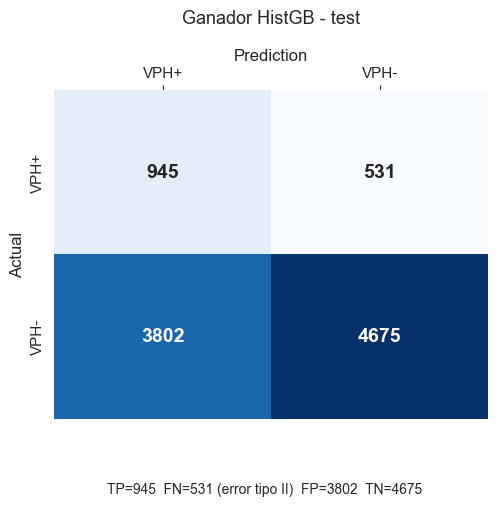

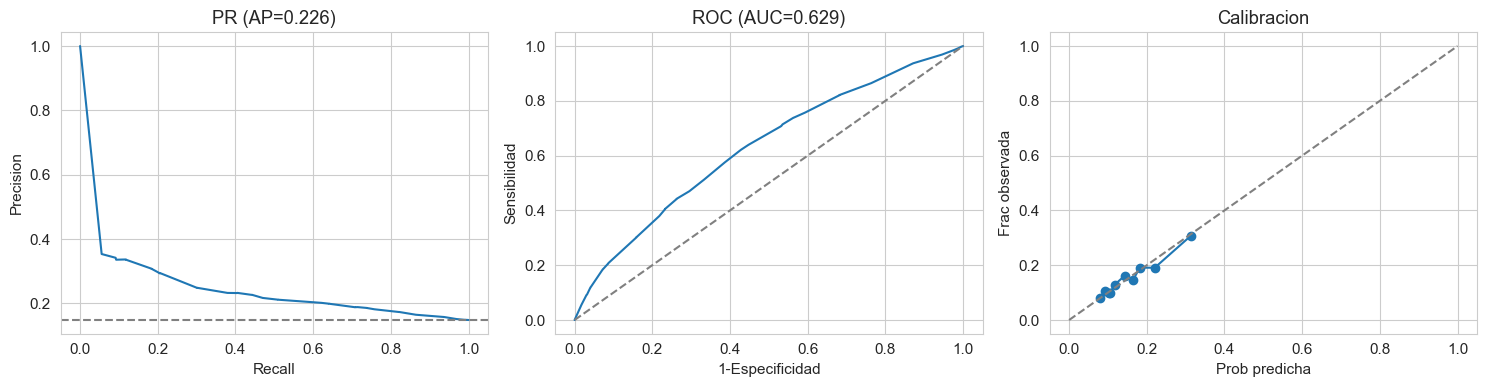

In [26]:
# Reporte de clasificacion, matriz de confusion y curvas sobre el test
yp = (pte >= UMBRAL_CAMPEON).astype(int)
print(classification_report(yte, yp, target_names=["VPH-", "VPH+"]))
plot_confusion(yte, pte, UMBRAL_CAMPEON, f"Ganador {CAMPEON} - test")

prec, rec, _ = precision_recall_curve(yte, pte); fpr, tpr, _ = roc_curve(yte, pte)
ptt, ptp = calibration_curve(yte, pte, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(rec, prec); ax[0].axhline(yte.mean(), ls="--", color="gray"); ax[0].set_title(f"PR (AP={prauc_te:.3f})"); ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
ax[1].plot(fpr, tpr); ax[1].plot([0, 1], [0, 1], "--", color="gray"); ax[1].set_title(f"ROC (AUC={roc_te:.3f})"); ax[1].set_xlabel("1-Especificidad"); ax[1].set_ylabel("Sensibilidad")
ax[2].plot(ptp, ptt, "o-"); ax[2].plot([0, 1], [0, 1], "--", color="gray"); ax[2].set_title("Calibracion"); ax[2].set_xlabel("Prob predicha"); ax[2].set_ylabel("Frac observada")
plt.tight_layout(); plt.show()

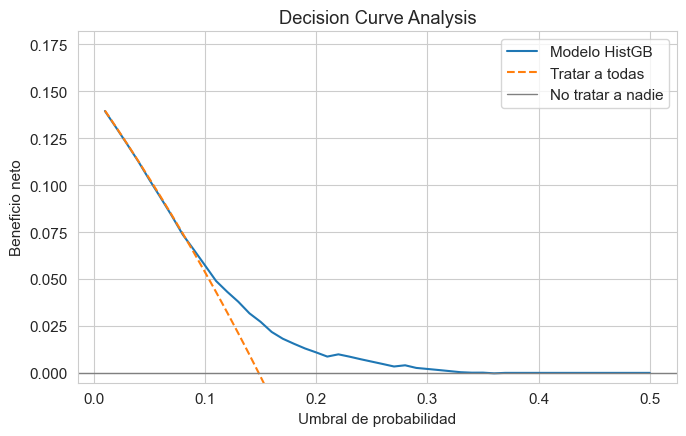

In [27]:
# Analisis de curva de decision (beneficio neto): util si la curva del modelo supera a "tratar a todas" y "a nadie"
def net_benefit(y, p, pt):
    yp = (p >= pt).astype(int); n = len(y)
    tp = ((yp == 1) & (y == 1)).sum(); fp = ((yp == 1) & (y == 0)).sum()
    return tp/n - fp/n * (pt/(1-pt))
ts = np.linspace(0.01, 0.5, 50)
nb_model = [net_benefit(yte, pte, t) for t in ts]
nb_all = [yte.mean() - (1-yte.mean())*(t/(1-t)) for t in ts]
plt.figure(figsize=(7, 4.5))
plt.plot(ts, nb_model, label=f"Modelo {CAMPEON}"); plt.plot(ts, nb_all, "--", label="Tratar a todas")
plt.axhline(0, color="gray", lw=1, label="No tratar a nadie")
plt.xlabel("Umbral de probabilidad"); plt.ylabel("Beneficio neto"); plt.legend()
plt.title("Decision Curve Analysis"); plt.ylim(bottom=min(0, min(nb_model))-0.005); plt.tight_layout(); plt.show()

Equidad por grupo de edad (mismo umbral del campeon):
  <30    n=1868  Recall=0.902  Precision=0.240  FP=1194  FN= 41
  30-45  n=5009  Recall=0.581  Precision=0.185  FP=1756  FN=287
  >45    n=3058  Recall=0.453  Precision=0.165  FP=849  FN=203

Global: TP=945 FP=3802 FN=531 TN=4675  Recall=0.640  Precision=0.199


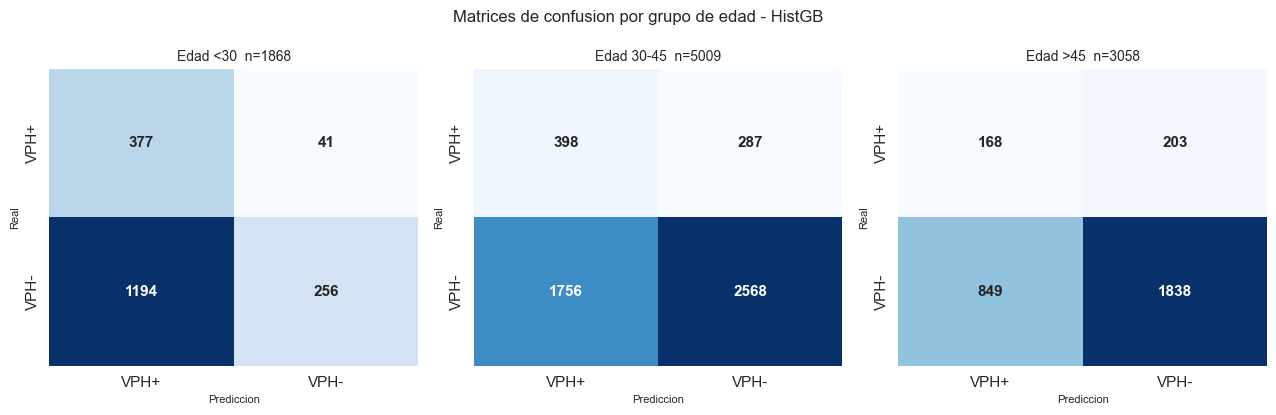

In [28]:
# Falsos negativos/positivos y equidad del modelo por grupo de edad
edad_te = pd.to_numeric(X_test["edad"], errors="coerce").values[_m]
grupos = {"<30": edad_te < 30, "30-45": (edad_te >= 30) & (edad_te <= 45), ">45": edad_te > 45}
print("Equidad por grupo de edad (mismo umbral del campeon):")
for g, msk in grupos.items():
    if msk.sum() == 0: continue
    mm = evaluate_model(yte[msk], pte[msk], UMBRAL_CAMPEON)
    print(f"  {g:6s} n={int(msk.sum()):4d}  Recall={mm['Recall']:.3f}  Precision={mm['Precision']:.3f}  FP={mm['FP']:3d}  FN={mm['FN']:3d}")
glob = evaluate_model(yte, pte, UMBRAL_CAMPEON)
print(f"\nGlobal: TP={glob['TP']} FP={glob['FP']} FN={glob['FN']} TN={glob['TN']}  Recall={glob['Recall']:.3f}  Precision={glob['Precision']:.3f}")

# Matriz de confusion del campeon en cada grupo de edad
gv = [(g, m) for g, m in grupos.items() if m.sum() > 0]
fig, axes = plt.subplots(1, len(gv), figsize=(4.3*len(gv), 4.2)); axes = np.atleast_1d(axes)
for ax, (g, msk) in zip(axes, gv):
    cm_on_ax(ax, yte[msk], pte[msk], UMBRAL_CAMPEON, f"Edad {g}  n={int(msk.sum())}")
plt.suptitle(f"Matrices de confusion por grupo de edad - {CAMPEON}", fontsize=12)
plt.tight_layout(); plt.show()

Comparacion base vs ganador sobre los casos completos del test, n = 9908
          modelo    AUC  Brier     F1  Recall  Precision   FP  FN    MCC  umbral
 Modelo base GLM 0.6267 0.1230 0.3015  0.6571     0.1957 3971 504 0.1326  0.1326
Ganador (HistGB) 0.6284 0.1227 0.2981  0.7136     0.1884 4518 421 0.1276  0.1087


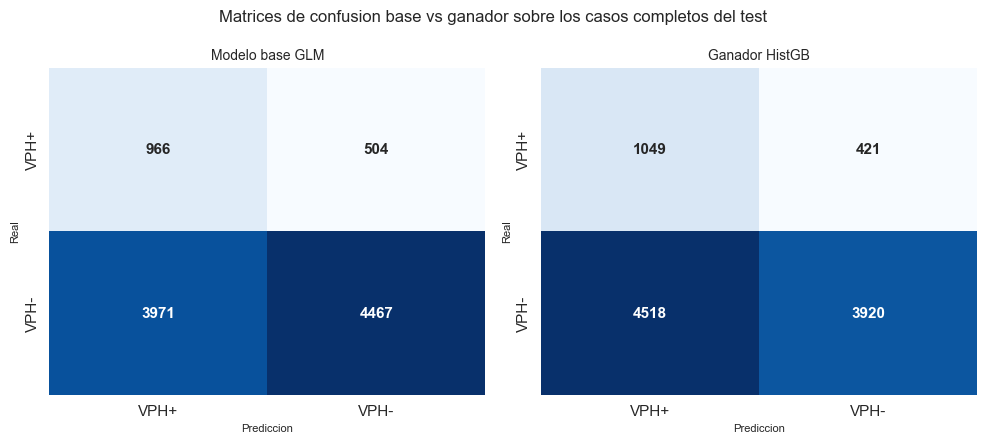

In [ ]:
# Comparacion base GLM vs ganador, en las mismas metricas, sobre los casos completos del test.
glm_cols2 = [c for c in df_glm.columns if c != "res_vph"]
df_tr2 = X_train[glm_cols2].copy(); df_te2 = X_test[glm_cols2].copy()
for c in [v for v in glm_cols2 if v in CAT_COLS]:
    df_tr2[c] = df_tr2[c].astype("string"); df_te2[c] = df_te2[c].astype("string")
df_tr2["res_vph"] = y_train.values; df_te2["res_vph"] = y_test.values
df_tr2 = df_tr2.dropna().reset_index(drop=True); df_te2 = df_te2.dropna().reset_index(drop=True)
yt2, Xt2 = dmatrices(formula_final, data=df_tr2, return_type="dataframe")
glm_base2 = sm.GLM(yt2, Xt2, family=sm.families.Binomial()).fit()
Xte2 = build_design_matrices([Xt2.design_info], df_te2)[0]
proba_base_te = np.asarray(glm_base2.predict(np.asarray(Xte2)))
y_base_te = df_te2["res_vph"].values.astype(int)

mask_win = X_test[glm_cols2].copy()
for c in [v for v in glm_cols2 if v in CAT_COLS]: mask_win[c] = mask_win[c].astype("string")
mask_win = mask_win.notna().all(axis=1).values & _m
proba_win_te = proba_test[mask_win]; y_win_te = y_test.values[mask_win]

def panel(nombre, y, p):
    th = find_threshold(y, p); mm = evaluate_model(y, p, th)
    return dict(modelo=nombre, AUC=roc_auc_score(y, p), Brier=brier_score_loss(y, p),
                F1=mm["F1"], Recall=mm["Recall"], Precision=mm["Precision"], FP=mm["FP"], FN=mm["FN"],
                MCC=matthews_corrcoef(y, (p >= th).astype(int)), umbral=round(th, 4))
cmp = pd.DataFrame([panel("Modelo base GLM", y_base_te, proba_base_te),
                    panel(f"Ganador ({CAMPEON})", y_win_te, proba_win_te)])
print("Comparacion base vs ganador sobre los casos completos del test, n =", len(y_base_te))
print(cmp[["modelo", "AUC", "Brier", "F1", "Recall", "Precision", "FP", "FN", "MCC", "umbral"]].round(4).to_string(index=False))

# Matriz de confusion de cada modelo comparado, al umbral F1 que le corresponde
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
cm_on_ax(axes[0], y_base_te, proba_base_te, find_threshold(y_base_te, proba_base_te), "Modelo base GLM")
cm_on_ax(axes[1], y_win_te, proba_win_te, find_threshold(y_win_te, proba_win_te), f"Ganador {CAMPEON}")
plt.suptitle("Matrices de confusion base vs ganador sobre los casos completos del test", fontsize=12)
plt.tight_layout(); plt.show()

### Análisis de la Fase 4, techo de rendimiento y decisión

**Desempeño en la prueba.** Sobre las 9.953 pacientes nunca vistas el mejor modelo HistGB alcanza un PR-AUC de 0.226, cuyo intervalo de confianza del 95 por ciento va de 0.210 a 0.243 y supera de forma modesta el piso de 0.148 que marca la prevalencia. Obtiene un AUC ROC de 0.629 con intervalo entre 0.613 y 0.645 y un Brier de 0.123 que confirma unas probabilidades bien calibradas. En el punto de corte elegido detecta al 64 por ciento de las positivas con una precisión del 20 por ciento y un F1 de 0.30, un perfil coherente con el objetivo de no dejar pasar casos a cambio de aceptar bastantes alarmas falsas.

**El techo de rendimiento.** Estas cifras no son fruto del azar de este modelo, coinciden con las del modelo base GLM, de AUC cercano a 0.63, y con las que arrojaron los análisis previos del proyecto. Se probó un conjunto amplio de modelos que abarca regresión logística, RandomForest, cuatro variantes de gradiente potenciado y una red neuronal, con calibración, búsqueda de la mejor estrategia de balanceo y ajuste fino del umbral, y todos convergen al mismo valor, un AUC en torno a 0.63 y un F1-score en torno a 0.30. Se concluye que el límite lo imponen las variables disponibles y no el algoritmo, pues lo que este dataset permite distinguir sobre el resultado de VPH es intrínsecamente moderado.

**Base frente a ganador.** Comparados sobre los 9.908 casos completos de la prueba, el modelo base GLM, con AUC 0.627 y F1 0.302, y el ganador HistGB, con AUC 0.628 y F1 0.298, resultan estadísticamente indistinguibles. La única ventaja real del ganador reside en que a su umbral detecta más positivas, con una sensibilidad de 0.71 frente a 0.66 y 83 falsos negativos menos, a cambio de más falsos positivos. No mejora por tanto la capacidad de discriminación, simplemente opera en un punto más sensible que conviene al triaje.

**Equidad.** Se observa una brecha importante por edad. La sensibilidad es de 0.90 en las menores de 30 años, desciende a 0.58 entre los 30 y los 45 y cae a 0.45 en las mayores de 45. El modelo detecta muy bien a las pacientes jóvenes positivas y se muestra débil con las de mayor edad, lo que debe advertirse de forma explícita, ya que no conviene emplearlo como único criterio para descartar riesgo en las mujeres mayores.

**Decisión sobre el uso.** Dada la discriminación modesta en torno a un AUC de 0.63 y la brecha de equidad descrita, no procede emplear este modelo como herramienta diagnóstica autónoma. Sí procede en cambio como apoyo al triaje, puesto que entrega un porcentaje de riesgo calibrado, respaldado por un Brier de 0.123, que ayuda a priorizar a quién citar primero para citología y seguimiento, siempre bajo supervisión clínica y con la advertencia sobre las pacientes de mayor edad. Queda por tanto como una aprobación condicionada a un uso de priorización asistida y no de decisión clínica final.


---
## Seccion 5: Exportacion del modelo ganador

Se guarda por último el modelo ganador junto con su punto de corte para que el prototipo lo cargue y lo utilice sin reentrenarlo. La exportación se hace en dos pasos. Primero se guarda el artefacto adaptado al tipo de modelo. Si se trata de un modelo de scikit-learn se guarda el conjunto formado por el preprocesador, el clasificador y el calibrador. Si se trata de la red neuronal se guarda el archivo en formato keras con su preprocesador y su calibrador. Si se trata del GLM base se guarda su objeto de statsmodels con la información de diseño. En todos los casos se escribe un archivo umbral.json con el punto de corte y las métricas, y se define la función que entrega el porcentaje de riesgo de resultado positivo para cualquier paciente. Después, en una celda de verificación, se recarga el artefacto de forma aislada y se predice sobre algunas filas de prueba, para confirmar que funciona  y entrega el mismo porcentaje sin depender del cuaderno.


In [30]:
# Exportacion del ganador + umbral + funcion de porcentaje de riesgo
import joblib
os.makedirs("artifacts", exist_ok=True)
meta = {"campeon": str(CAMPEON), "tipo": TIPO_CAMPEON, "umbral": UMBRAL_CAMPEON,
        "estrategia_balanceo": str(SAMPLER_WIN), "metrica_seleccion": "F1+menorFP",
        "test_PR_AUC": float(prauc_te), "test_ROC_AUC": float(roc_te), "test_Brier": float(brier_te)}
if TIPO_CAMPEON == "keras":
    ARTEFACTO.save("artifacts/modelo_vph.keras")
    joblib.dump(pre_fin, "artifacts/preprocesador.joblib")
    joblib.dump(iso_keras, "artifacts/calibrador.joblib")
    meta["archivos"] = ["modelo_vph.keras", "preprocesador.joblib", "calibrador.joblib"]
elif TIPO_CAMPEON == "glm":
    ARTEFACTO.save("artifacts/modelo_vph_glm.pickle")
    joblib.dump({"formula": formula_final, "design_info": GLM_DESIGN, "glm_cols": glm_cols,
                 "cat_cols": [c for c in glm_cols if c in CAT_COLS]}, "artifacts/glm_meta.joblib")
    meta["archivos"] = ["modelo_vph_glm.pickle", "glm_meta.joblib"]
else:
    joblib.dump(ARTEFACTO, "artifacts/modelo_vph.joblib")
    meta["archivos"] = ["modelo_vph.joblib"]
with open("artifacts/umbral.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print("Exportado a artifacts/:", json.dumps(meta, ensure_ascii=False, indent=2))

def riesgo_pct(prob):
    """Convierte la probabilidad de VPH positivo en porcentaje de riesgo para el personal de salud."""
    return round(float(prob) * 100, 1)

Exportado a artifacts/: {
  "campeon": "HistGB",
  "tipo": "sklearn",
  "umbral": 0.13025210084033614,
  "estrategia_balanceo": "sin_balanceo",
  "metrica_seleccion": "F1+menorFP",
  "test_PR_AUC": 0.22581235685664214,
  "test_ROC_AUC": 0.6286900022474331,
  "test_Brier": 0.12260467019582778,
  "archivos": [
    "modelo_vph.joblib"
  ]
}


In [31]:
# Verificacion de carga: recargar el artefacto de forma aislada y predecir 3 filas del test
umb = json.load(open("artifacts/umbral.json", encoding="utf-8")); thr = umb["umbral"]
filas3 = X_test.iloc[:3]
if umb["tipo"] == "keras":
    pre2 = joblib.load("artifacts/preprocesador.joblib"); cal2 = joblib.load("artifacts/calibrador.joblib")
    from tensorflow import keras as _k; mdl2 = _k.models.load_model("artifacts/modelo_vph.keras")
    pr = cal2.predict(mdl2.predict(pre2.transform(filas3), verbose=0).ravel())
elif umb["tipo"] == "glm":
    g2 = sm.load("artifacts/modelo_vph_glm.pickle"); gm = joblib.load("artifacts/glm_meta.joblib")
    d3 = filas3[gm["glm_cols"]].copy()
    for c in gm["cat_cols"]: d3[c] = d3[c].astype("string")
    Xd = build_design_matrices([gm["design_info"]], d3)[0]; pr = np.asarray(g2.predict(np.asarray(Xd)))
else:
    art = joblib.load("artifacts/modelo_vph.joblib")
    pr = art["iso"].predict(art["clf"].predict_proba(art["pre"].transform(filas3))[:, 1])
for i, p in enumerate(pr):
    et = "VPH+ (priorizar)" if p >= thr else "VPH- (rutina)"
    print(f"Paciente {i+1}: riesgo = {riesgo_pct(p)} %  ->  {et}")
print("Verificacion OK: el artefacto recarga y predice sin reentrenar.")

Paciente 1: riesgo = 17.3 %  ->  VPH+ (priorizar)
Paciente 2: riesgo = 12.1 %  ->  VPH- (rutina)
Paciente 3: riesgo = 8.0 %  ->  VPH- (rutina)
Verificacion OK: el artefacto recarga y predice sin reentrenar.
